# Airline Loyalty Program - Behavioral Intelligence Pipeline



## SECTION 0 - Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
 'figure.dpi': 120,
 'axes.titlesize': 13,
 'axes.titleweight': 'bold',
 'axes.labelsize': 11,
 'figure.facecolor': 'white'
})

import os
os.makedirs('plots', exist_ok=True)


## SECTION 1 - Data Loading



In [2]:
df_flight = pd.read_csv('data/Customer Flight Activity.csv')
df_loyalty = pd.read_csv('data/Customer Loyalty History.csv')
df_calendar = pd.read_csv('data/Calendar.csv')

print(f"Flight Activity {df_flight.shape[0]:,} rows × {df_flight.shape[1]} cols")
print(f"Loyalty History {df_loyalty.shape[0]:,} rows × {df_loyalty.shape[1]} cols")
print(f"Calendar Data {df_calendar.shape[0]:,} rows × {df_calendar.shape[1]} cols")

Flight Activity 392,936 rows × 8 cols
Loyalty History 16,737 rows × 16 cols
Calendar Data 2,557 rows × 4 cols


In [3]:
print("=== FLIGHT ACTIVITY — First 3 Rows ===")
display(df_flight.head(3))

print("\n=== LOYALTY HISTORY — First 3 Rows ===")
display(df_loyalty.head(3))

print("\n=== CALENDAR — First 3 Rows ===")
display(df_calendar.head(3))

=== FLIGHT ACTIVITY — First 3 Rows ===


,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0



=== LOYALTY HISTORY — First 3 Rows ===


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0



=== CALENDAR — First 3 Rows ===


,Date,Start of Year,Start of Quarter,Start of Month
0,01-01-2012,01-01-2012,01-01-2012,01-01-2012
1,02-01-2012,01-01-2012,01-01-2012,01-01-2012
2,03-01-2012,01-01-2012,01-01-2012,01-01-2012


## SECTION 2 - Data Quality Audit

### 2.1 Missing Values - Flight Activity


In [4]:
missing_flight = df_flight.isna().sum()
print("Flight Activity — Missing Values:")
print(missing_flight)
print("\n No missing values." if missing_flight.sum() == 0 else "\n Missing values found!")

Flight Activity — Missing Values:
Loyalty Number                 0
Year                           0
Month                          0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

 No missing values.


### 2.2 Missing Values — Loyalty History

In [5]:
missing_loyalty = df_loyalty.isna().sum()
print("Loyalty History — Missing Values:")
print(missing_loyalty[missing_loyalty > 0])

Loyalty History — Missing Values:
Salary                 4238
Cancellation Year     14670
Cancellation Month    14670
dtype: int64


 Two types of missingness here - very different meanings:
- **Salary NULLs (4,238)** - Not random. 100% tied to "College" education group. A systemic data capture failure, not noise.
- **Cancellation NULLs (14,670)** - These are NOT errors. NULL cancellation = member is still active. Only ~2,067 people actually cancelled.


### 2.3 Visualize Missing Value Pattern

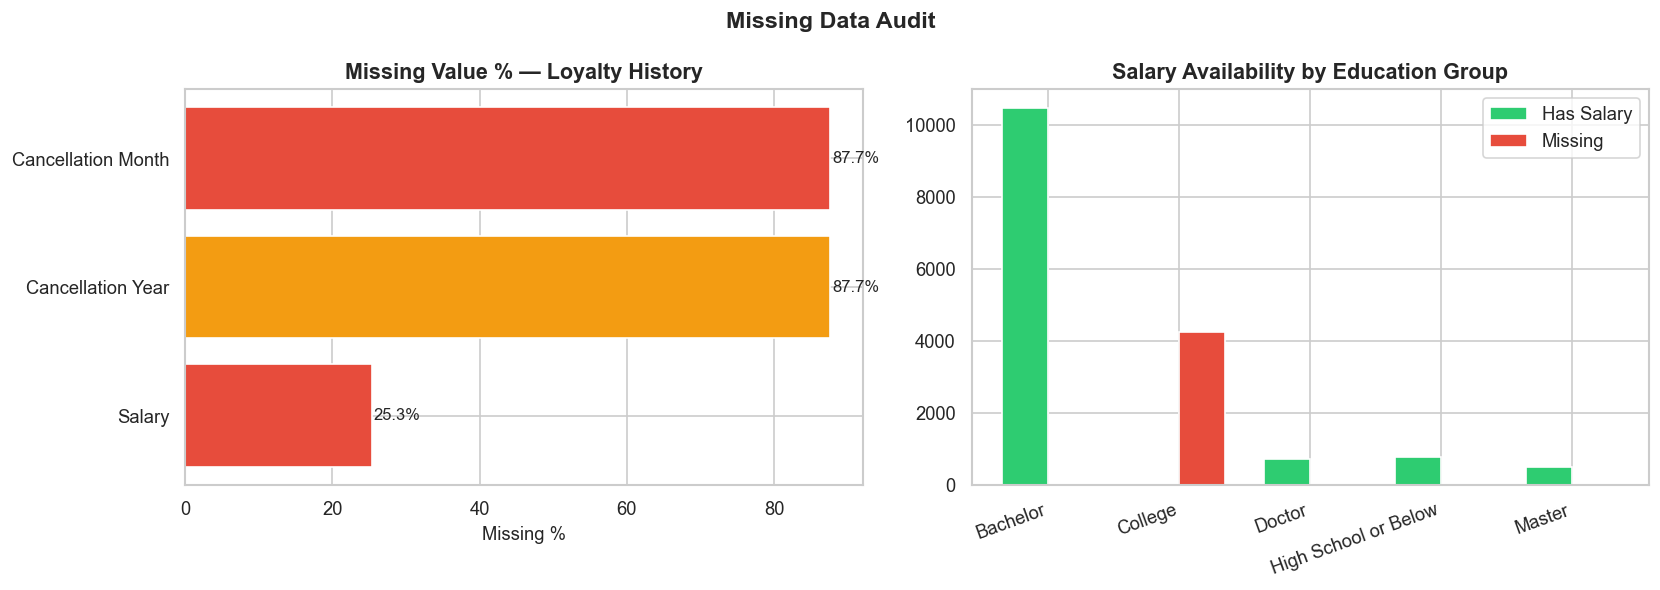

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Missing % by column
missing_pct = (df_loyalty.isna().sum() / len(df_loyalty)) * 100
missing_pct = missing_pct[missing_pct > 0]
bars = axes[0].barh(missing_pct.index, missing_pct.values,
 color=['#e74c3c', '#f39c12'], edgecolor='white')
axes[0].set_xlabel("Missing %")
axes[0].set_title("Missing Value % — Loyalty History")
for i, v in enumerate(missing_pct.values):
 axes[0].text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=10)

# Right: Salary missing vs Education group
salary_audit = df_loyalty.groupby('Education').agg(
 Total=('Salary', 'size'),
 Missing=('Salary', lambda x: x.isna().sum())
).reset_index()
salary_audit['Available'] = salary_audit['Total'] - salary_audit['Missing']
x = np.arange(len(salary_audit))
w = 0.35
axes[1].bar(x - w/2, salary_audit['Available'], w, label='Has Salary', color='#2ecc71', edgecolor='white')
axes[1].bar(x + w/2, salary_audit['Missing'], w, label='Missing', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(salary_audit['Education'], rotation=20, ha='right')
axes[1].set_title("Salary Availability by Education Group")
axes[1].legend()

plt.suptitle("Missing Data Audit", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_missing_audit.png', dpi=120, bbox_inches='tight')
plt.show()

** Key Insight:** College group has **100% missing salary** . We cannot impute from other groups (different income distribution). Decision: fill with 0.0 and add a flag column `Is_Salary_Unknown`.


### 2.4 Duplicate Audit - Flight Activity

In [7]:
exact_dups = df_flight.duplicated().sum()
key_dups = df_flight.duplicated(subset=['Loyalty Number', 'Year', 'Month']).sum()

print(f"Exact Row Duplicates (identical rows) : {exact_dups:,}")
print(f"Month-Key Overlaps (split log entries) : {key_dups:,}")


Exact Row Duplicates (identical rows) : 1,922
Month-Key Overlaps (split log entries) : 3,871


Strategy:
 Exact duplicates DROP (logging bug, same event recorded twice)
 Key overlaps AGGREGATE with SUM (real data split across rows)

### 2.5 Show a Live Duplicate Example

In [8]:
overlap_groups = df_flight.groupby(['Loyalty Number', 'Year', 'Month']).size()
sample_key = overlap_groups[overlap_groups > 1].index[0]

example = df_flight[
 (df_flight['Loyalty Number'] == sample_key[0]) &
 (df_flight['Year'] == sample_key[1]) &
 (df_flight['Month'] == sample_key[2])
]
print(f"Example: Loyalty #{sample_key[0]} | Year {sample_key[1]} | Month {sample_key[2]}")
display(example)
print("\n These two rows represent the SAME month. Summing them gives the true value.")

Example: Loyalty #101902 | Year 2017 | Month 1


,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
177037,101902,2017,1,0,0,0.0,0,0
177038,101902,2017,1,0,0,0.0,0,0



 These two rows represent the SAME month. Summing them gives the true value.


### 2.6 Negative Salary Detection

In [9]:
neg_salary_count = (df_loyalty['Salary'] < 0).sum()
print(f"Negative Salary Records Found : {neg_salary_count}")
print(f"Min Salary in Raw Data : {df_loyalty['Salary'].min():,.0f}")


Negative Salary Records Found : 20
Min Salary in Raw Data : -58,486


 Negative salary is impossible — data entry error.
 Fix: clip(lower=0) during preprocessing.

## SECTION 3 - Preprocessing

### 3.1 Loyalty History -Text Cleaning, Imputation & Feature Engineering


In [10]:
# Step 1: Strip whitespace from all string columns
str_cols = ['Country', 'Province', 'City', 'Gender', 'Education',
 'Marital Status', 'Loyalty Card', 'Enrollment Type']
for col in str_cols:
 df_loyalty[col] = df_loyalty[col].astype(str).str.strip()

# Step 2: Fix negative salary (data entry error)
df_loyalty['Salary'] = df_loyalty['Salary'].clip(lower=0)

# Step 3: Impute missing salary for College group 0.0
# Add flag so model knows this is unknown, not truly zero
df_loyalty['Is_Salary_Unknown'] = df_loyalty['Salary'].isna().astype(int)
df_loyalty['Salary'] = df_loyalty['Salary'].fillna(0.0)

# Step 4: Cancellation binary flag
# NULL cancellation = still active customer
df_loyalty['Formally_Cancelled'] = np.where(df_loyalty['Cancellation Year'].isna(), 0, 1)

# Step 5: Customer tenure in months (up to Dec 2018 — dataset end)
df_loyalty['Customer_Tenure_Months'] = (
 (2018 - df_loyalty['Enrollment Year']) * 12 +
 (12 - df_loyalty['Enrollment Month'])
)

# Step 6: Fill cancellation date nulls with 0 for clean export
df_loyalty['Cancellation Year'] = df_loyalty['Cancellation Year'].fillna(0).astype(int)
df_loyalty['Cancellation Month'] = df_loyalty['Cancellation Month'].fillna(0).astype(int)

print(" Loyalty Preprocessing Complete")
print(f" Formally Cancelled Members : {df_loyalty['Formally_Cancelled'].sum():,}")
print(f" College Salary Unknown Flag : {df_loyalty['Is_Salary_Unknown'].sum():,}")
print(f" Avg Customer Tenure : {df_loyalty['Customer_Tenure_Months'].mean():.1f} months")
print(f" Min Salary (after clip) : {df_loyalty['Salary'].min():,.0f}")

 Loyalty Preprocessing Complete
 Formally Cancelled Members : 2,067
 College Salary Unknown Flag : 4,238
 Avg Customer Tenure : 38.3 months
 Min Salary (after clip) : 0


### 3.2 Visualize Tenure & Cancellation Distribution

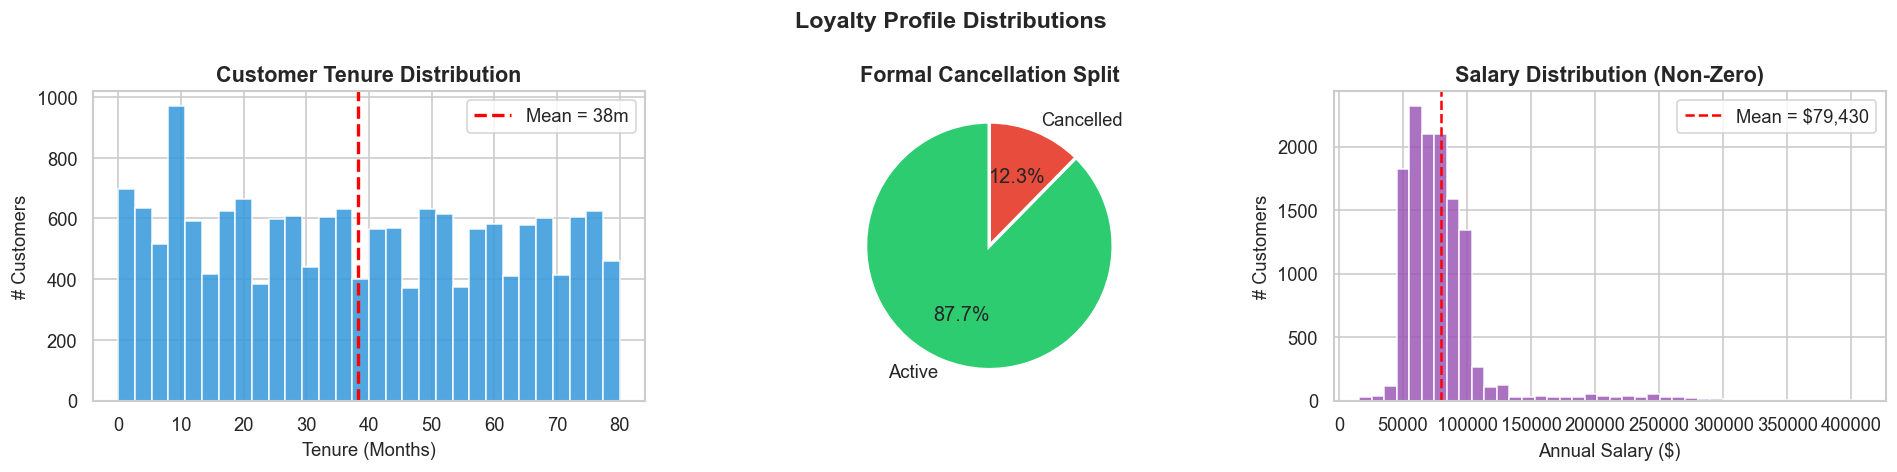

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tenure distribution
axes[0].hist(df_loyalty['Customer_Tenure_Months'], bins=30,
 color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df_loyalty['Customer_Tenure_Months'].mean(),
 color='red', linestyle='--', linewidth=2, label=f"Mean = {df_loyalty['Customer_Tenure_Months'].mean():.0f}m")
axes[0].set_title("Customer Tenure Distribution")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("# Customers")
axes[0].legend()

# Cancellation pie
cancel_counts = df_loyalty['Formally_Cancelled'].value_counts()
axes[1].pie(cancel_counts.values,
 labels=['Active', 'Cancelled'],
 colors=['#2ecc71', '#e74c3c'],
 autopct='%1.1f%%', startangle=90,
 wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Formal Cancellation Split")

# Salary distribution (after fix)
salary_nonzero = df_loyalty[df_loyalty['Salary'] > 0]['Salary']
axes[2].hist(salary_nonzero, bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].axvline(salary_nonzero.mean(), color='red', linestyle='--',
 label=f"Mean = ${salary_nonzero.mean():,.0f}")
axes[2].set_title("Salary Distribution (Non-Zero)")
axes[2].set_xlabel("Annual Salary ($)")
axes[2].set_ylabel("# Customers")
axes[2].legend()

plt.suptitle("Loyalty Profile Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_tenure_cancellation_salary.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.3 Flight Activity - Deduplication & Aggregation

In [12]:
print(f"Before cleaning : {len(df_flight):,} rows")

df_flight_clean = (
 df_flight
 .drop_duplicates() # Remove exact clones
 .groupby(['Loyalty Number', 'Year', 'Month']) # Group by customer-month key
 .agg({
 'Total Flights' : 'sum', # Sum split entries
 'Distance' : 'sum',
 'Points Accumulated' : 'sum',
 'Points Redeemed' : 'sum',
 'Dollar Cost Points Redeemed' : 'sum'
 })
 .reset_index()
)

remaining_key_dups = df_flight_clean.duplicated(subset=['Loyalty Number','Year','Month']).sum()
neg_values = (df_flight_clean[['Total Flights','Distance','Points Accumulated']] < 0).sum().sum()

print(f"After cleaning : {len(df_flight_clean):,} rows")
print(f"Rows removed : {len(df_flight) - len(df_flight_clean):,}")
print(f"Key duplicates remaining (expect 0): {remaining_key_dups}")
print(f"Negative values (expect 0) : {neg_values}")

Before cleaning : 392,936 rows
After cleaning : 389,065 rows
Rows removed : 3,871
Key duplicates remaining (expect 0): 0
Negative values (expect 0) : 0


### 3.4 Calendar - Build Lightweight Lookup Table

In [13]:
calendar_records = [
 {'Year': y, 'Month': m, 'Quarter': f"Q{(m-1)//3 + 1}"}
 for y in [2017, 2018]
 for m in range(1, 13)
]
df_calendar_clean = pd.DataFrame(calendar_records)

print(f" Calendar Lookup: {len(df_calendar_clean)} month-year combinations")
display(df_calendar_clean)

 Calendar Lookup: 24 month-year combinations


,Year,Month,Quarter
0,2017,1,Q1
1,2017,2,Q1
2,2017,3,Q1
3,2017,4,Q2
4,2017,5,Q2
5,2017,6,Q2
6,2017,7,Q3
7,2017,8,Q3
8,2017,9,Q3
9,2017,10,Q4


## SECTION 4 - Dataset Integration (Master Merge)

### 4.1 Three-Way Merge Pipeline


In [14]:
# Step 1: Map quarter info to monthly flight logs
df_flight_cal = pd.merge(df_flight_clean, df_calendar_clean, on=['Year', 'Month'], how='left')

df_combined = pd.merge(df_flight_cal, df_loyalty, on='Loyalty Number', how='inner')

print(f"After Merge Shape : {df_combined.shape[0]:,} rows × {df_combined.shape[1]} columns")
print()
print("All 26 columns in merged dataset:")
for i, col in enumerate(df_combined.columns, 1):
 print(f" {i:2d}. {col}")

After Merge Shape : 389,065 rows × 27 columns

All 26 columns in merged dataset:
  1. Loyalty Number
  2. Year
  3. Month
  4. Total Flights
  5. Distance
  6. Points Accumulated
  7. Points Redeemed
  8. Dollar Cost Points Redeemed
  9. Quarter
 10. Country
 11. Province
 12. City
 13. Postal Code
 14. Gender
 15. Education
 16. Salary
 17. Marital Status
 18. Loyalty Card
 19. CLV
 20. Enrollment Type
 21. Enrollment Year
 22. Enrollment Month
 23. Cancellation Year
 24. Cancellation Month
 25. Is_Salary_Unknown
 26. Formally_Cancelled
 27. Customer_Tenure_Months


### 4.2 Merged Data - Sanity Check & Distributions

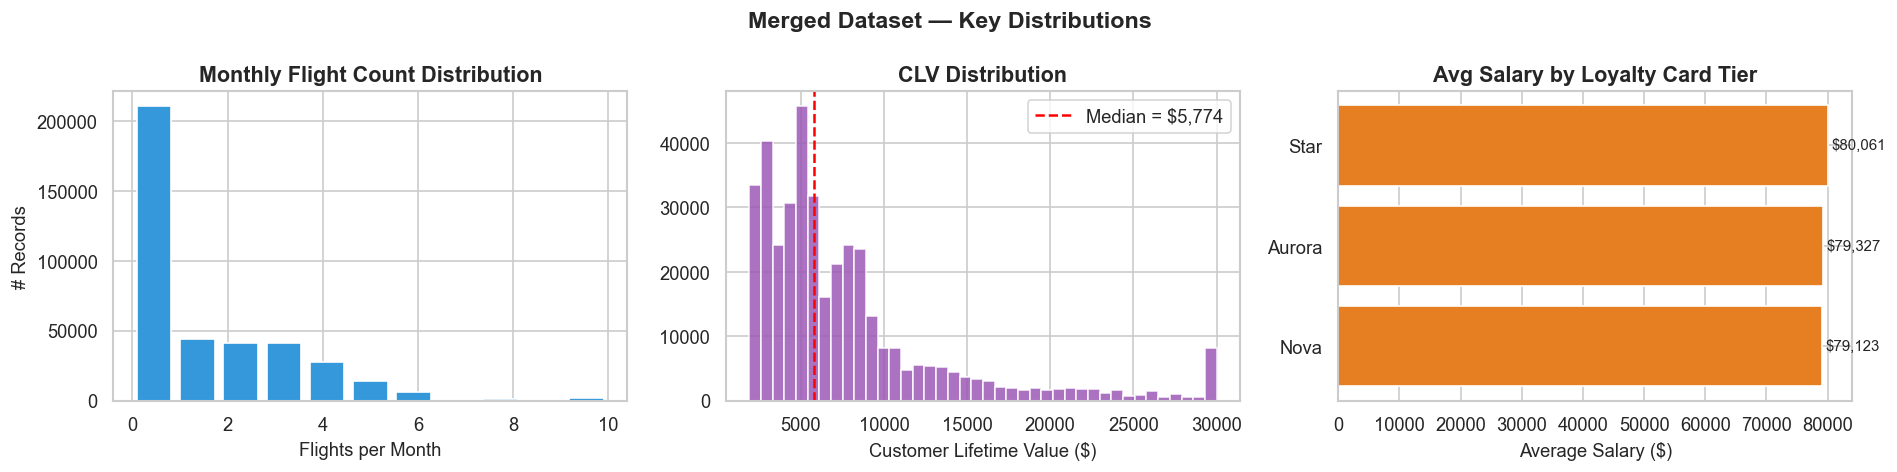

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Monthly flight count distribution
flight_clipped = df_combined['Total Flights'].clip(upper=10)
axes[0].hist(flight_clipped, bins=11, color='#3498db', edgecolor='white', rwidth=0.8)
axes[0].set_title("Monthly Flight Count Distribution")
axes[0].set_xlabel("Flights per Month")
axes[0].set_ylabel("# Records")

# CLV distribution
axes[1].hist(df_combined['CLV'].clip(upper=30000), bins=40,
 color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].axvline(df_combined['CLV'].median(), color='red', linestyle='--',
 label=f"Median = ${df_combined['CLV'].median():,.0f}")
axes[1].set_title("CLV Distribution")
axes[1].set_xlabel("Customer Lifetime Value ($)")
axes[1].legend()

# Average salary by loyalty card tier
card_salary = df_combined[df_combined['Salary'] > 0].groupby('Loyalty Card')['Salary'].mean().sort_values()
axes[2].barh(card_salary.index, card_salary.values, color='#e67e22', edgecolor='white')
axes[2].set_title("Avg Salary by Loyalty Card Tier")
axes[2].set_xlabel("Average Salary ($)")
for i, v in enumerate(card_salary.values):
 axes[2].text(v + 500, i, f"${v:,.0f}", va='center', fontsize=9)

plt.suptitle("Merged Dataset — Key Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_merged_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.3 Save Master Combined File

In [16]:
df_combined.to_csv('data/Customer_Loyalty_Flights_Combined.csv', index=False)
print(" Master combined file saved data/Customer_Loyalty_Flights_Combined.csv")
print(f" Shape: {df_combined.shape[0]:,} rows × {df_combined.shape[1]} columns")
print(f" Null values: {df_combined.isnull().sum().sum()}")

 Master combined file saved data/Customer_Loyalty_Flights_Combined.csv
 Shape: 389,065 rows × 27 columns
 Null values: 0


## SECTION 5 - Feature Engineering

### 5.1 Customer-Grain Collapse (389K rows 16,737 rows)

**Collapsing monthly rows into one signature row per customer.**


In [17]:
df_cust_base = df_combined.groupby('Loyalty Number').agg({
 # Behavioral totals — SUM over 2 years
 'Total Flights' : 'sum',
 'Distance' : 'sum',
 'Points Accumulated' : 'sum',
 'Points Redeemed' : 'sum',
 'Dollar Cost Points Redeemed' : 'sum',

 # Static profile fields — same value in every row, use FIRST
 'Customer_Tenure_Months' : 'first',
 'Is_Salary_Unknown' : 'first',
 'Salary' : 'first',
 'CLV' : 'first',
 'Formally_Cancelled' : 'first',
 'Loyalty Card' : 'first',
 'Education' : 'first',
 'Marital Status' : 'first',
 'Gender' : 'first',
 'Enrollment Type' : 'first',
 'Province' : 'first', 
}).reset_index()

# Clean column names
df_cust_base.rename(columns={
 'Total Flights' : 'Total_Flights_2Yr',
 'Distance' : 'Total_Distance_2Yr',
 'Points Accumulated' : 'Points_Accumulated_2Yr',
 'Points Redeemed' : 'Points_Redeemed_2Yr',
 'Dollar Cost Points Redeemed' : 'Cost_Redeemed_2Yr'
}, inplace=True)

print(f" Collapsed to Customer Grain: {df_cust_base.shape[0]:,} customers × {df_cust_base.shape[1]} columns")
display(df_cust_base.head(3))

 Collapsed to Customer Grain: 16,737 customers × 17 columns


,Loyalty Number,Total_Flights_2Yr,Total_Distance_2Yr,Points_Accumulated_2Yr,Points_Redeemed_2Yr,Cost_Redeemed_2Yr,Customer_Tenure_Months,Is_Salary_Unknown,Salary,CLV,Formally_Cancelled,Loyalty Card,Education,Marital Status,Gender,Enrollment Type,Province
0,100018,46,81190,81190.0,1513,272,28,0,92552.0,7919.20,0,Aurora,Bachelor,Married,Female,Standard,Alberta
1,100102,51,68918,68918.0,1195,215,69,1,0.0,2887.74,0,Nova,College,Single,Male,Standard,Ontario
2,100140,47,72856,72856.0,593,107,29,1,0.0,2838.07,0,Nova,College,Divorced,Female,Standard,British Columbia


### 5.2 Recency - Months Since Last Flight

In [18]:
# Create date column from Year + Month
df_combined['Activity_Date'] = pd.to_datetime(
 df_combined['Year'].astype(str) + '-' + df_combined['Month'].astype(str) + '-01'
)

# Find last month where customer actually flew
df_active = df_combined[df_combined['Total Flights'] > 0]
df_recency = df_active.groupby('Loyalty Number')['Activity_Date'].max().reset_index()
df_recency.rename(columns={'Activity_Date': 'Last_Flight_Date'}, inplace=True)

df_features = pd.merge(df_cust_base, df_recency, on='Loyalty Number', how='left')

# Customers who NEVER flew assign date before window = max recency
df_features['Last_Flight_Date'] = df_features['Last_Flight_Date'].fillna(
 pd.to_datetime('2016-11-01')
)

# Months since last flight measured from Dec 2018 
df_features['Months_Since_Last_Flight'] = (
 (2018 - df_features['Last_Flight_Date'].dt.year) * 12 +
 (12 - df_features['Last_Flight_Date'].dt.month)
)

print(" Recency Feature Added")
print(df_features['Months_Since_Last_Flight'].describe(percentiles=[.5,.75,.9,.95]).round(1))

 Recency Feature Added
count    16737.0
mean         3.7
std          7.6
min          0.0
50%          0.0
75%          2.0
90%         21.0
95%         25.0
max         25.0
Name: Months_Since_Last_Flight, dtype: float64


`2016-11-01` for customers who never flew?
Our window is Jan 2017–Dec 2018. Assigning Nov 2016 gives them 25 months of recency — the maximum possible — cleanly marking them as the coldest customers without a separate flag.


### 5.3 Activity Consistency - Active Months Ratio

In [19]:
df_combined['Is_Active_Month'] = (df_combined['Total Flights'] > 0).astype(int)

df_active_months = df_combined.groupby('Loyalty Number')['Is_Active_Month'].sum().reset_index()
df_features = pd.merge(df_features, df_active_months, on='Loyalty Number', how='left')

df_features['Active_Months_Ratio'] = df_features['Is_Active_Month'] / 24.0
df_features.drop(columns=['Is_Active_Month'], inplace=True)

print(" Active Months Ratio Added")
print("Distribution:")
print(df_features['Active_Months_Ratio'].describe(percentiles=[.25,.5,.75,.9]).round(3))

 Active Months Ratio Added
Distribution:
count    16737.000
mean         0.443
std          0.237
min          0.000
25%          0.250
50%          0.500
75%          0.625
90%          0.708
max          1.000
Name: Active_Months_Ratio, dtype: float64


### 5.4 Seasonal Preference - Holiday Season Flight Ratio

In [20]:
# Sum flights per customer per quarter
df_quarterly = (
 df_combined
 .groupby(['Loyalty Number', 'Quarter'])['Total Flights']
 .sum()
 .unstack(fill_value=0)
 .reset_index()
)
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
 if q not in df_quarterly.columns:
  df_quarterly[q] = 0

df_features = pd.merge(df_features, df_quarterly, on='Loyalty Number', how='left')

# Holiday ratio = share of flights in Q3 (summer) + Q4 (holiday season)
df_features['Holiday_Season_Flight_Ratio'] = np.where(
 df_features['Total_Flights_2Yr'] > 0,
 (df_features['Q3'] + df_features['Q4']) / df_features['Total_Flights_2Yr'],
 0.0
)
df_features.drop(columns=['Q1', 'Q2', 'Q3', 'Q4'], inplace=True)

print(" Holiday Season Ratio Added")
print(" 0.0 = flies only in Q1/Q2 (business traveler signal)")
print(" 1.0 = flies only in Q3/Q4 (leisure traveler signal)")

 Holiday Season Ratio Added
 0.0 = flies only in Q1/Q2 (business traveler signal)
 1.0 = flies only in Q3/Q4 (leisure traveler signal)


### 5.5 Behavioral Efficiency Ratios

In [21]:
# How much of earned points does the customer actually spend
df_features['Redemption_Rate'] = np.where(
 df_features['Points_Accumulated_2Yr'] > 0,
 df_features['Points_Redeemed_2Yr'] / df_features['Points_Accumulated_2Yr'],
 0.0
)

# Points earned per km — proxy for cabin class (business earns 2–3x economy per km)
df_features['Points_Per_KM'] = np.where(
 df_features['Total_Distance_2Yr'] > 0,
 df_features['Points_Accumulated_2Yr'] / df_features['Total_Distance_2Yr'],
 0.0
)

# Average dollar value per redeemed point
df_features['Dollar_Per_Redeemed_Point'] = np.where(
 df_features['Points_Redeemed_2Yr'] > 0,
 df_features['Cost_Redeemed_2Yr'] / df_features['Points_Redeemed_2Yr'],
 0.0
)
print(" Behavioral Ratios Added")
print(f" Customers with zero redemptions : {(df_features['Redemption_Rate'] == 0).sum():,}")
print(f" Customers with any redemption : {(df_features['Redemption_Rate'] > 0).sum():,}")

 Behavioral Ratios Added
 Customers with zero redemptions : 5,259
 Customers with any redemption : 11,478


** Why these ratios matter:**
- `Redemption_Rate`: Low = hoarder or disengaged. High = engaged and extracting value.
- `Points_Per_KM`: High = flying business class. Key signal for premium segment.
- `Dollar_Per_Redeemed_Point`: How efficiently they redeem — high value redeemers vs low value.


### 5.6 Max Consecutive Inactivity Streak

In [22]:
df_streak = df_combined.sort_values(['Loyalty Number', 'Year', 'Month']).copy()

# A month is inactive if: zero flights AND zero redemptions
df_streak['is_inactive'] = (
 (df_streak['Total Flights'] == 0) & (df_streak['Points Redeemed'] == 0)
).astype(int)

# Calculate consecutive inactive month streak per customer
df_streak['gap_streak'] = df_streak.groupby('Loyalty Number')['is_inactive'].transform(
 lambda x: x * (x.groupby((~x.astype(bool)).cumsum()).cumcount() + 1)
)

df_max_gap = df_streak.groupby('Loyalty Number')['gap_streak'].max().reset_index()
df_max_gap.rename(columns={'gap_streak': 'Max_Inactivity_Streak'}, inplace=True)
df_features = pd.merge(df_features, df_max_gap, on='Loyalty Number', how='left')

print(" Max Inactivity Streak Added")
print(df_features['Max_Inactivity_Streak'].describe(percentiles=[.5,.75,.9,.95]).round(1))

 Max Inactivity Streak Added
count    16737.0
mean         8.2
std          7.2
min          0.0
50%          4.0
75%         11.0
90%         23.0
95%         24.0
max         24.0
Name: Max_Inactivity_Streak, dtype: float64


Why streak instead of total inactive months?
12 consecutive silent months is very different from 12 scattered quiet months. The streak captures **withdrawal behavior** — the single strongest early signal of churn. A customer gone 6+ months in a row is much more likely to never return than one with 6 sporadic quiet months.


### 5.7 Visualize All Engineered Features

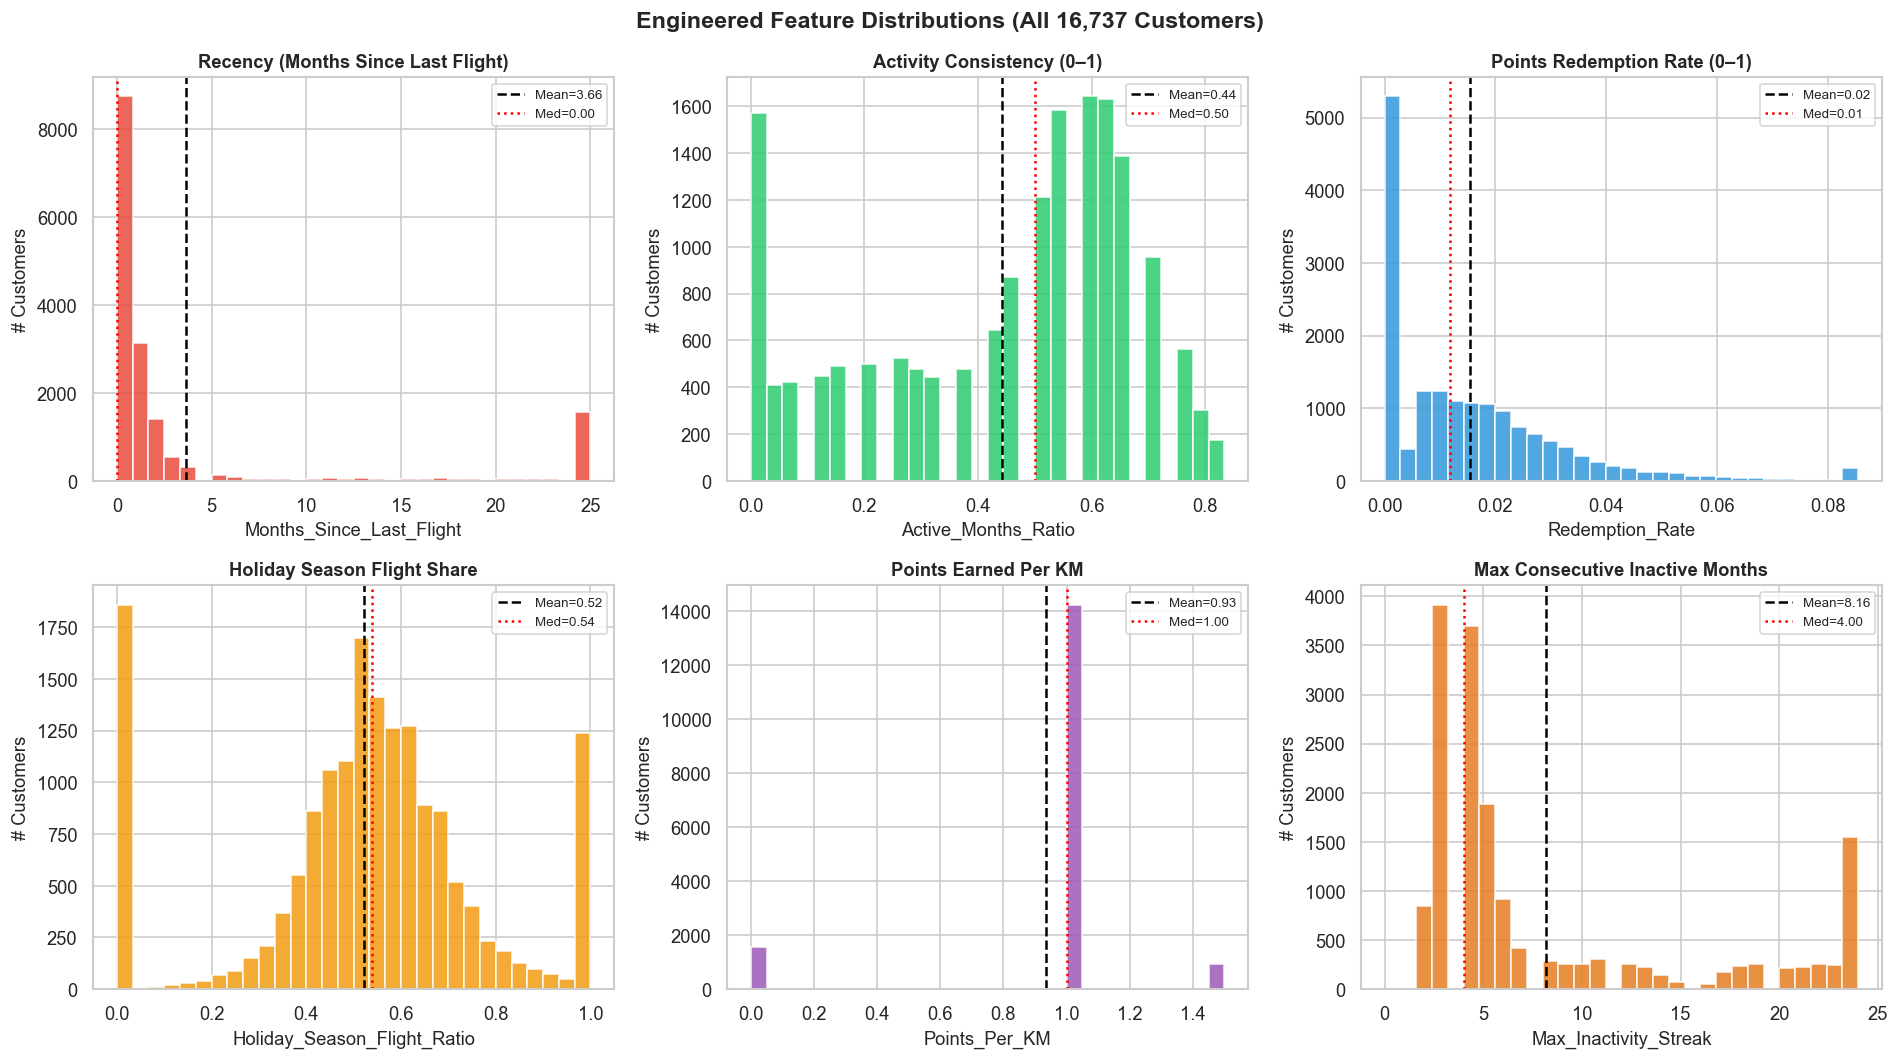

In [23]:
features_to_plot = [
 ('Months_Since_Last_Flight', '#e74c3c', 'Recency (Months Since Last Flight)'),
 ('Active_Months_Ratio', '#2ecc71', 'Activity Consistency (0–1)'),
 ('Redemption_Rate', '#3498db', 'Points Redemption Rate (0–1)'),
 ('Holiday_Season_Flight_Ratio', '#f39c12', 'Holiday Season Flight Share'),
 ('Points_Per_KM', '#9b59b6', 'Points Earned Per KM'),
 ('Max_Inactivity_Streak', '#e67e22', 'Max Consecutive Inactive Months'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, color, title) in zip(axes, features_to_plot):
 data = df_features[col].clip(upper=df_features[col].quantile(0.99))
 ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
 ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.2f}')
 ax.axvline(data.median(), color='red', linestyle=':', linewidth=1.5, label=f'Med={data.median():.2f}')
 ax.set_title(title, fontsize=11)
 ax.set_xlabel(col)
 ax.set_ylabel("# Customers")
 ax.legend(fontsize=8)

plt.suptitle("Engineered Feature Distributions (All 16,737 Customers)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_engineered_features.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.8 Outlier Capping - Winsorization

In [24]:
cap_cols = [
 'Total_Flights_2Yr', 
 'Total_Distance_2Yr', 
 'Points_Accumulated_2Yr', 
 'Salary', 
 'CLV' 
]

df_features_capped = df_features.copy()
cap_report = []

for col in cap_cols:
 lo = df_features[col].quantile(0.01)
 hi = df_features[col].quantile(0.95)
 df_features_capped[col] = df_features_capped[col].clip(lo, hi)
 cap_report.append({'Column': col, 'Floor (1%)': lo, 'Cap (95%)': hi,
 'Original Max': df_features[col].max()})

cap_df = pd.DataFrame(cap_report)
cap_df['Original Max'] = cap_df['Original Max'].apply(lambda x: f"{x:,.0f}")
cap_df['Floor (1%)'] = cap_df['Floor (1%)'].apply(lambda x: f"{x:,.0f}")
cap_df['Cap (95%)'] = cap_df['Cap (95%)'].apply(lambda x: f"{x:,.0f}")

print(" Winsorization Complete")
display(cap_df)

 Winsorization Complete


,Column,Floor (1%),Cap (95%),Original Max
0,Total_Flights_2Yr,0,53,106
1,Total_Distance_2Yr,0,"82,582","178,858"
2,Points_Accumulated_2Yr,0,"89,077","268,287"
3,Salary,0,"106,669","407,228"
4,CLV,"2,230","22,032","83,325"


### 5.9 Export - K-Means Input vs Full Master

In [25]:
# ── FULL MASTER (for dashboard + churn model) 
df_features_capped.to_csv('data/Customer_Master_Features_All.csv', index=False)

# ── K-MEANS INPUT (pure behavioral — no demographics, no leakage) 
drop_for_kmeans = [
 'Loyalty Number', 'Last_Flight_Date', 'Formally_Cancelled',
 'Cost_Redeemed_2Yr', 'Salary', 'CLV',
 'Loyalty Card', 'Education', 'Marital Status',
 'Gender', 'Enrollment Type', 'Province', 'Is_Salary_Unknown'
]
df_kmeans_input = df_features_capped.drop(columns=drop_for_kmeans)
df_kmeans_input.to_csv('data/Customer_Clustering_KMeans_Input.csv', index=False)

print(f" K-Means Input : {df_kmeans_input.shape[0]:,} customers × {df_kmeans_input.shape[1]} features")
print(f" Master Features : {df_features_capped.shape[0]:,} customers × {df_features_capped.shape[1]} columns")
print()
print("Features going into K-Means clustering:")
for f in df_kmeans_input.columns:
 print(f" {f}")

 K-Means Input : 16,737 customers × 12 features
 Master Features : 16,737 customers × 25 columns

Features going into K-Means clustering:
 Total_Flights_2Yr
 Total_Distance_2Yr
 Points_Accumulated_2Yr
 Points_Redeemed_2Yr
 Customer_Tenure_Months
 Months_Since_Last_Flight
 Active_Months_Ratio
 Holiday_Season_Flight_Ratio
 Redemption_Rate
 Points_Per_KM
 Dollar_Per_Redeemed_Point
 Max_Inactivity_Streak


## SECTION 6 - Correlation & Feature Relationships

### 6.1 Correlation Heatmap - K-Means Input Features


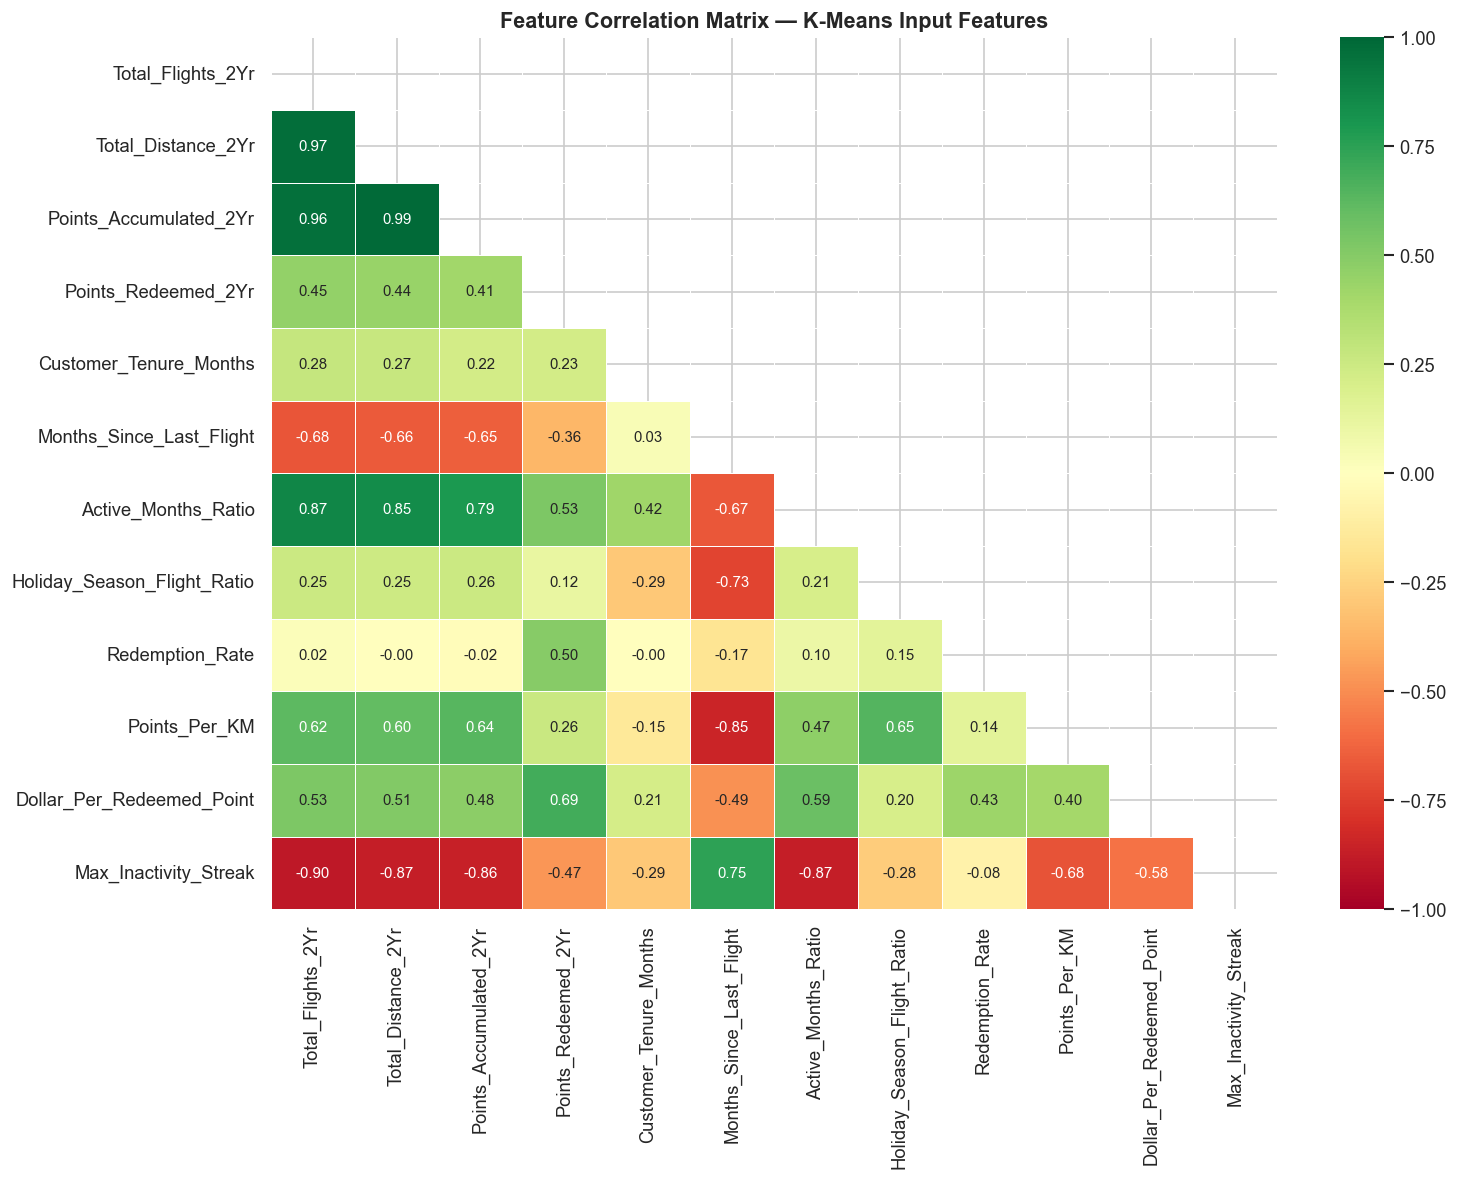

In [26]:
corr = df_kmeans_input.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool)) # Show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
 center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
 annot_kws={'size': 9})
ax.set_title("Feature Correlation Matrix — K-Means Input Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [27]:
drop_correlated = ['Total_Distance_2Yr', 'Points_Accumulated_2Yr', 
                   'Max_Inactivity_Streak', 'Points_Per_KM']

df_kmeans_input = df_kmeans_input.drop(columns=drop_correlated)

print(f"Features after dropping correlated: {df_kmeans_input.shape[1]}")
print(df_kmeans_input.columns.tolist())

Features after dropping correlated: 8
['Total_Flights_2Yr', 'Points_Redeemed_2Yr', 'Customer_Tenure_Months', 'Months_Since_Last_Flight', 'Active_Months_Ratio', 'Holiday_Season_Flight_Ratio', 'Redemption_Rate', 'Dollar_Per_Redeemed_Point']


### 6.2 Pairplot - Key Behavioral Features

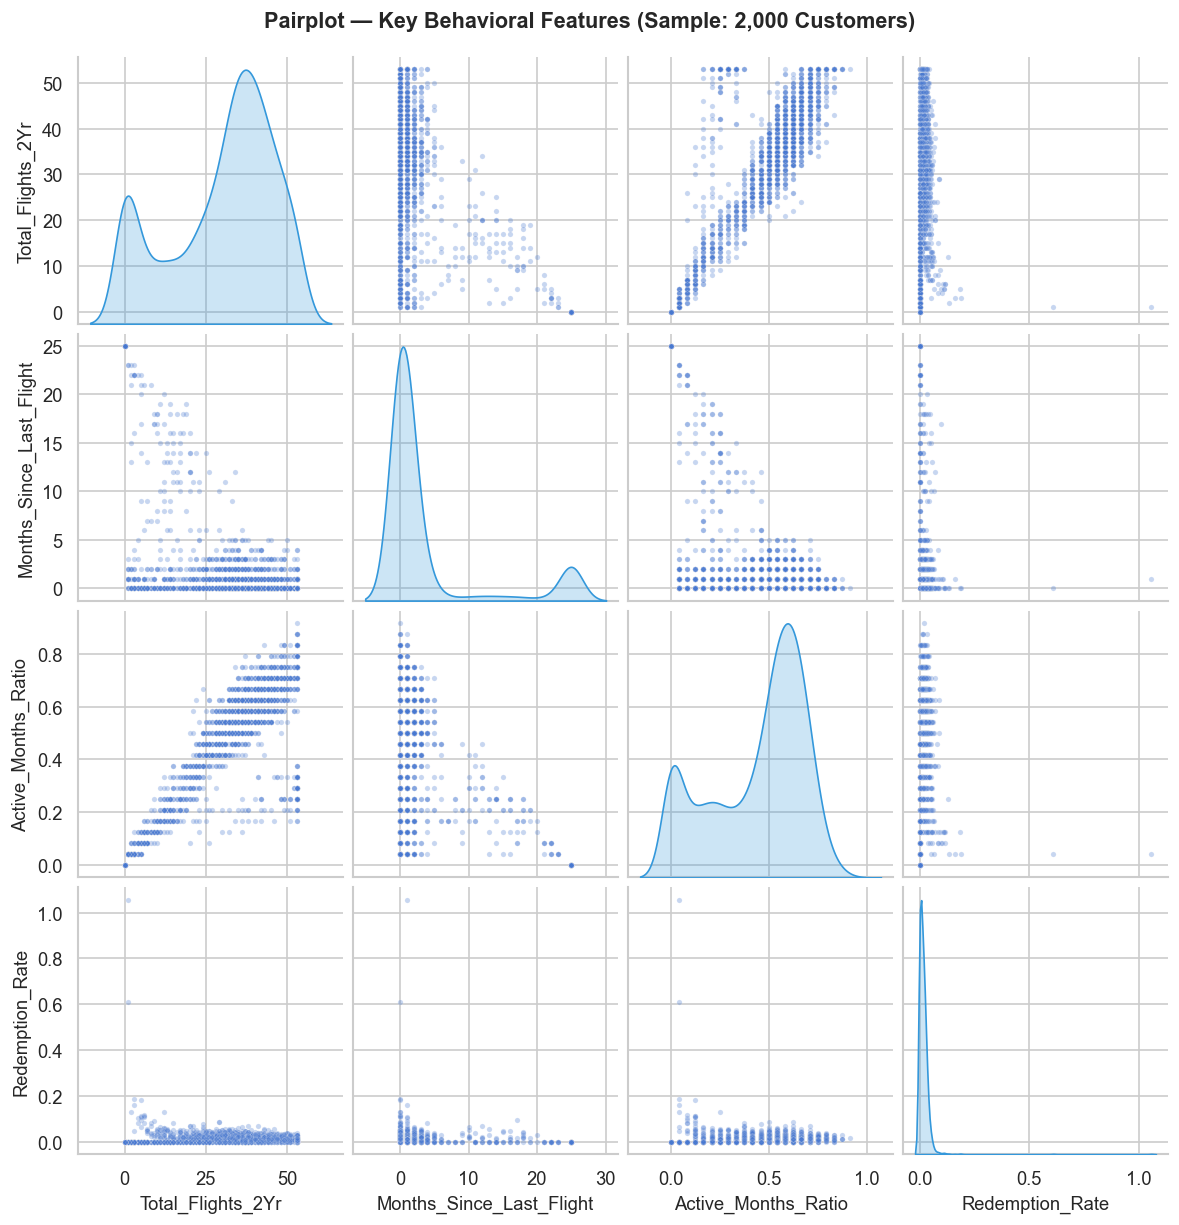

In [28]:
# Sample 2000 customers for readable pairplot
sample = df_kmeans_input.sample(2000, random_state=42)

plot_cols = ['Total_Flights_2Yr', 'Months_Since_Last_Flight',
 'Active_Months_Ratio', 'Redemption_Rate',]

g = sns.pairplot(sample[plot_cols], diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10},
 diag_kws={'color': '#3498db'})
g.figure.suptitle("Pairplot — Key Behavioral Features (Sample: 2,000 Customers)",
 y=1.02, fontsize=13, fontweight='bold')
plt.savefig('plots/06_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()


## SECTION 7 - Exploratory Data Analysis (EDA)
**Input:** `df_features_capped` - one row per customer 


### 7.0 - Working Dataset

In [29]:
df = df_features_capped
print(f"Working dataset: {df.shape[0]:,} customers x {df.shape[1]} columns")

Working dataset: 16,737 customers x 25 columns



### 7.1 - Flight Activity Distribution
 How many total flights did each customer take over 2 years?


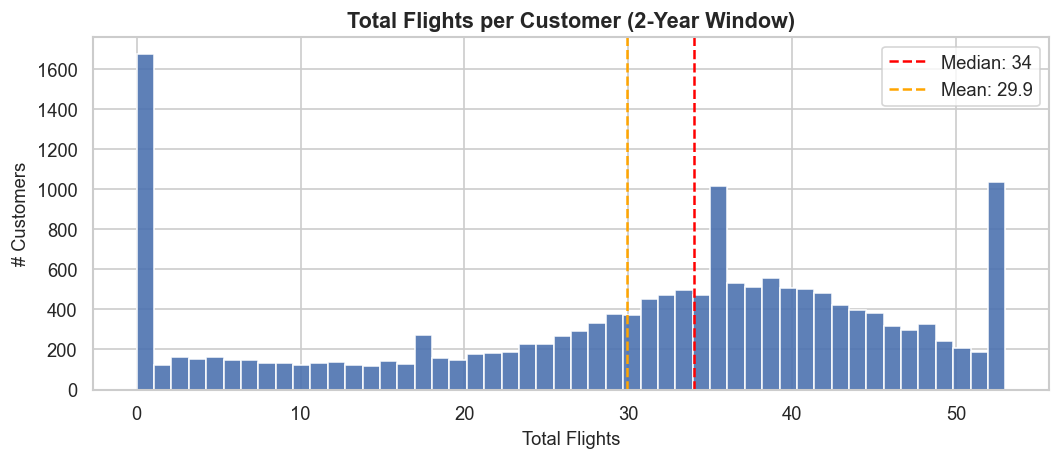

count    16737.00
mean        29.91
std         15.89
min          0.00
25%         20.00
50%         34.00
75%         42.00
max         53.00
Name: Total_Flights_2Yr, dtype: float64


In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['Total_Flights_2Yr'].clip(upper=80), bins=50,
 color='#4C72B0', edgecolor='white', alpha=0.9)
ax.axvline(df['Total_Flights_2Yr'].median(), color='red', linestyle='--',
 label=f"Median: {df['Total_Flights_2Yr'].median():.0f}")
ax.axvline(df['Total_Flights_2Yr'].mean(), color='orange',linestyle='--',
 label=f"Mean: {df['Total_Flights_2Yr'].mean():.1f}")
ax.set_title('Total Flights per Customer (2-Year Window)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Flights'); ax.set_ylabel('# Customers'); ax.legend()
plt.tight_layout()
plt.savefig('plots/07_01_flight_distribution.png', dpi=150)
plt.show()
print(df['Total_Flights_2Yr'].describe().round(2))

small inactive group (never flew) and a large active core flying roughly 2–3 flights per month consistently.


### 7.2 - Loyalty Card Tier Distribution
How many members hold each loyalty tier (Star, Nova, Aurora)?


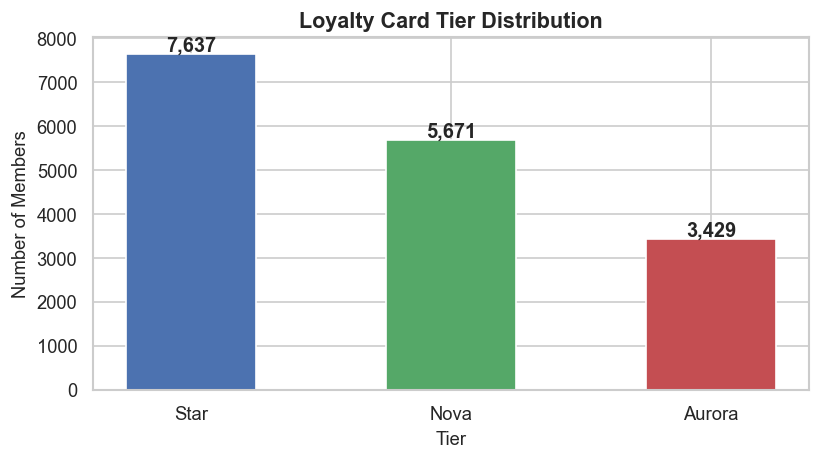

In [31]:
# 'Loyalty Card' is already in df (from df_features_capped)
tier_counts = df['Loyalty Card'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4C72B0','#55A868','#C44E52']
ax.bar(tier_counts.index, tier_counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(tier_counts.values):
 ax.text(i, v + 80, f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Loyalty Card Tier Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Tier'); ax.set_ylabel('Number of Members')
plt.tight_layout()
plt.savefig('plots/07_02_loyalty_tier.png', dpi=150)
plt.show()

 Star dominates, Aurora (VIP) is the smallest group. Aurora members need the strongest retention effort — losing one VIP hurts more than losing 10 Star members.


### 7.3 - CLV Distribution by Loyalty Tier
**What:** Boxplot of Customer Lifetime Value across tiers.
**Why:** Validates whether higher tier = higher CLV. 

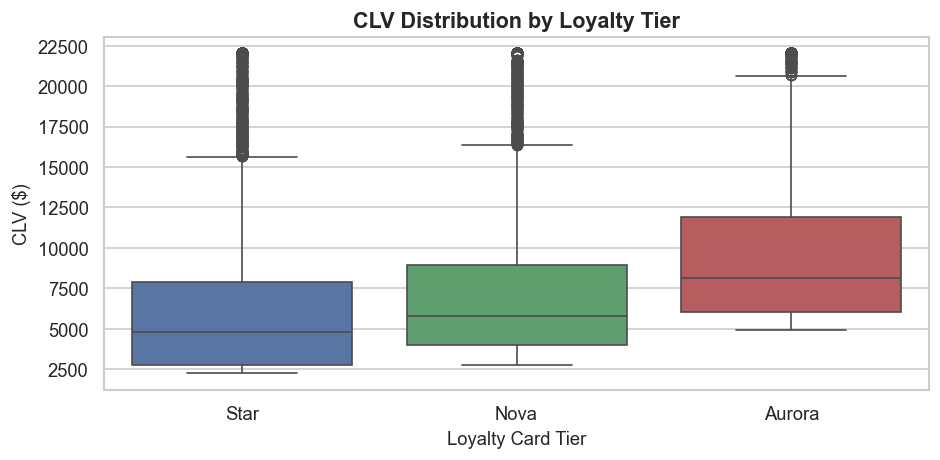

In [32]:
tier_order = [t for t in ['Star','Nova','Aurora'] if t in df['Loyalty Card'].unique()]
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='Loyalty Card', y='CLV', order=tier_order,
 palette=['#4C72B0','#55A868','#C44E52'], ax=ax)
ax.set_title('CLV Distribution by Loyalty Tier', fontsize=13, fontweight='bold')
ax.set_xlabel('Loyalty Card Tier'); ax.set_ylabel('CLV ($)')
plt.tight_layout()
plt.savefig('plots/07_03_clv_by_tier.png', dpi=150)
plt.show()


### 7.4 - Active Months Ratio Distribution
**What:** What fraction of the 24 months did each customer actually fly? (0 = never flew, 1 = flew every month)
**Why:** This is a core churn signal. Customers with ratio near 0 are disengaged. 

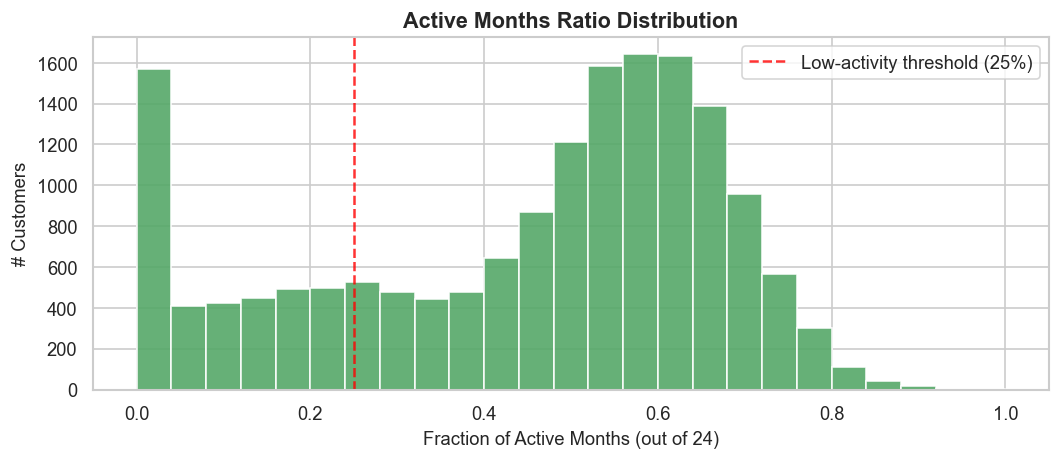

 22.9% of customers were active in fewer than 6 of 24 months


In [33]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['Active_Months_Ratio'], bins=25, color='#55A868', edgecolor='white', alpha=0.9)
ax.axvline(0.25, color='red', linestyle='--', alpha=0.8, label='Low-activity threshold (25%)')
ax.set_title('Active Months Ratio Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Fraction of Active Months (out of 24)')
ax.set_ylabel('# Customers'); ax.legend()
plt.tight_layout()
plt.savefig('plots/07_04_active_months_ratio.png', dpi=150)
plt.show()
low_pct = (df['Active_Months_Ratio'] < 0.25).mean() * 100
print(f" {low_pct:.1f}% of customers were active in fewer than 6 of 24 months")

** Insight:** Large spike near 0 = massive dormant base still enrolled in the program.
Smaller bump at high ratios = your loyal flying core. These two groups will become distinct K-Means clusters.

### 7.5 - Points Redemption Rate Distribution
**What:** What fraction of earned points did each customer actually spend?
**Why:** Low redemption = disengaged customer OR point hoarder. Both groups behave differently. Zero redemption is a strong early churn signal.

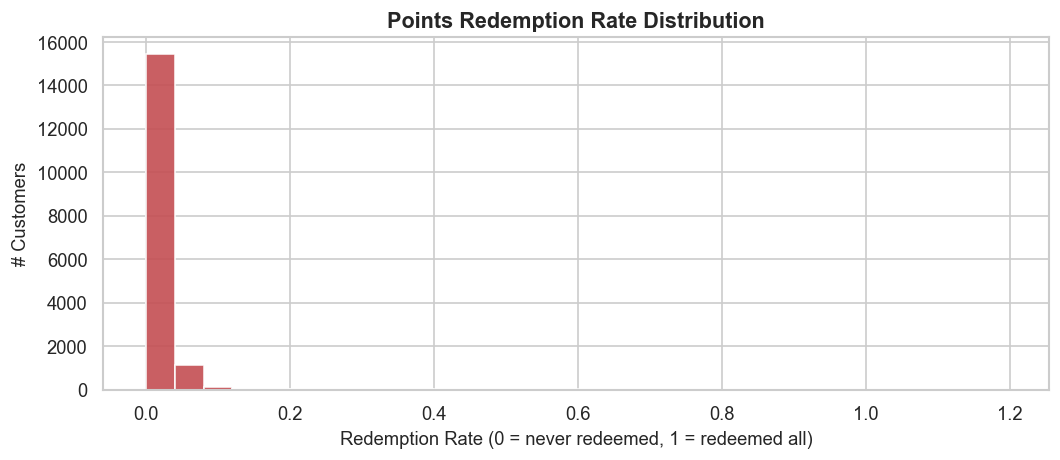

 31.4% of customers have NEVER redeemed a single point


In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['Redemption_Rate'], bins=30, color='#C44E52', edgecolor='white', alpha=0.9)
ax.set_title('Points Redemption Rate Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Redemption Rate (0 = never redeemed, 1 = redeemed all)')
ax.set_ylabel('# Customers')
plt.tight_layout()
plt.savefig('plots/07_05_redemption_rate.png', dpi=150)
plt.show()
zero_pct = (df['Redemption_Rate'] == 0).mean() * 100
print(f" {zero_pct:.1f}% of customers have NEVER redeemed a single point")

** Insight:** Most customers have 0 redemption. They accumulate points but never use them.
This is a disengagement signal AND a financial liability (unredeemed points sit on the airline's balance sheet as debt). Prompting redemption = reducing churn + reducing liability.


### 7.7 - Salary vs CLV Scatter (by Education)
**What:** Does higher salary translate to higher CLV?
**Why:** If yes, salary is a valid segmentation dimension. Also reveals the College=0 salary cluster 

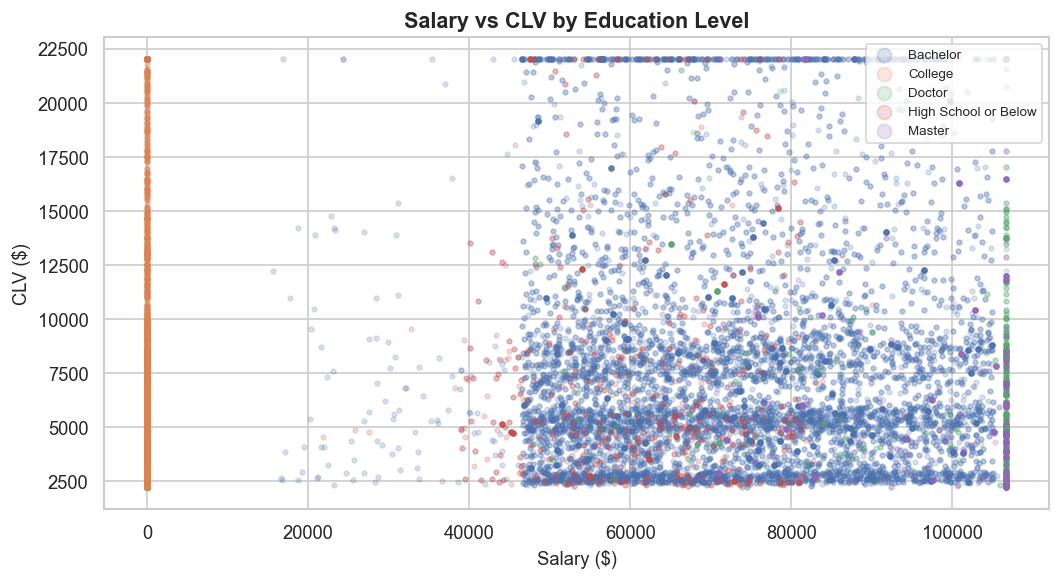

In [35]:
palette = {'Bachelor':'#4C72B0','College':'#DD8452','Doctor':'#55A868',
           'High School or Below':'#C44E52','Master':'#9467BD'}

fig, ax = plt.subplots(figsize=(9, 5))
for edu, grp in df.groupby('Education'):
    ax.scatter(grp['Salary'], grp['CLV'], alpha=0.2, s=8,
               label=edu, color=palette.get(edu, 'grey'))
ax.set_title('Salary vs CLV by Education Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Salary ($)'); ax.set_ylabel('CLV ($)')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.savefig('plots/07_07_salary_clv_scatter.png', dpi=150)
plt.show()

** Insight:** College members cluster along Salary=0 (imputed — known data gap).
For other education groups, salary and CLV show a mild positive relationship. Doctors show the highest CLV ceiling — high-income frequent travellers.


## SECTION 8 - Churn Label Definition
**Goal:** Create a binary churn label (0/1) for each customer based on behavior -- not formal cancellation.

**Our definition:**
> A customer is **churned (=1)** if they had >= 6 consecutive months of **zero flights AND zero redemption**.


### 8.1 - Compute Max Consecutive Inactivity Streak


In [36]:
df_sorted = df_combined.sort_values(['Loyalty Number','Year','Month']).copy()

# Flag each month as inactive: no flights AND no redemption
df_sorted['is_inactive'] = (
 (df_sorted['Total Flights'] == 0) &
 (df_sorted['Points Redeemed'] == 0)
).astype(int)

def max_streak(series):
 """Find longest consecutive run of 1s in a series."""
 max_s, cur = 0, 0
 for v in series:
  cur = cur + 1 if v == 1 else 0
 max_s = max(max_s, cur)
 return max_s

df_streaks = (df_sorted
 .groupby('Loyalty Number')['is_inactive']
 .apply(max_streak)
 .reset_index())
df_streaks.columns = ['Loyalty Number', 'Max_Inactive_Streak']

print("Max Inactive Streak -- Distribution:")
print(df_streaks['Max_Inactive_Streak'].describe().round(2))

Max Inactive Streak -- Distribution:
count    16737.00
mean         3.49
std          7.30
min          0.00
25%          0.00
50%          0.00
75%          2.00
max         24.00
Name: Max_Inactive_Streak, dtype: float64



### 8.2 - Assign Churn Label (Threshold = 6 months)


In [37]:
CHURN_THRESHOLD = 6

df_streaks['Churn_Label'] = (df_streaks['Max_Inactive_Streak'] >= CHURN_THRESHOLD).astype(int)

# Merge into customer-grain dataset
df = df.merge(df_streaks[['Loyalty Number','Max_Inactive_Streak','Churn_Label']],
 on='Loyalty Number', how='left')

counts = df['Churn_Label'].value_counts()
print(f"Not Churned (0): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"Churned (1): {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")

Not Churned (0): 14,282 (85.3%)
Churned (1): 2,455 (14.7%)



### 8.3 - Visualize Churn Label Distribution


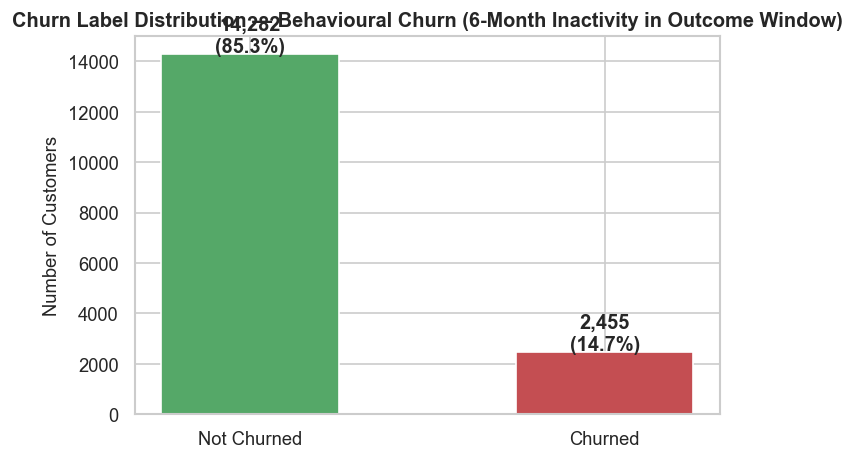

In [38]:
counts = df['Churn_Label'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Not Churned','Churned'], [counts[0], counts[1]],
 color=['#55A868','#C44E52'], edgecolor='white', width=0.5)
for bar, v in zip(bars, [counts[0], counts[1]]):
 ax.text(bar.get_x() + bar.get_width()/2, v + 80,
 f'{v:,}\n({v/len(df)*100:.1f}%)',
 ha='center', fontweight='bold')
ax.set_title('Churn Label Distribution — Behavioural Churn (6-Month Inactivity in Outcome Window)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('plots/08_01_churn_distribution.png', dpi=150)
plt.show()


### 8.4 - Inactive Streak Distribution
**What:** Histogram of max inactivity streaks across all customers.
**Why:** Shows whether the 6-month threshold is a natural break point or arbitrary. We want to see a density drop around 5-6 months confirming the threshold makes sense.

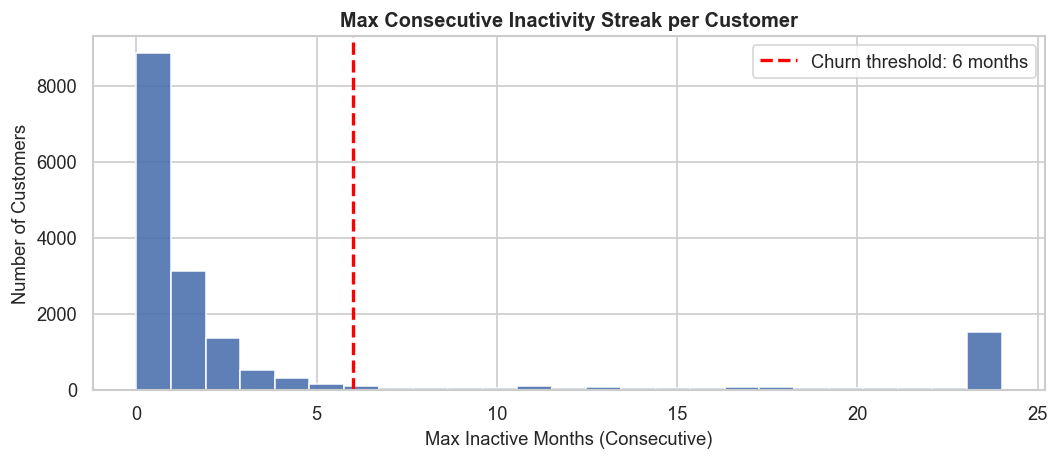

In [39]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['Max_Inactive_Streak'], bins=25,
 color='#4C72B0', edgecolor='white', alpha=0.9)
ax.axvline(CHURN_THRESHOLD, color='red', linestyle='--', linewidth=2,
 label=f'Churn threshold: {CHURN_THRESHOLD} months')
ax.set_title('Max Consecutive Inactivity Streak per Customer', fontsize=12, fontweight='bold')
ax.set_xlabel('Max Inactive Months (Consecutive)'); ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig('plots/08_02_streak_distribution.png', dpi=150)
plt.show()

** Expected pattern:** Two spikes — one near 0 (active customers) and one near 24 (completely inactive). The 6-month red line separates casual pauses from true churn.


### 8.5 - Churn Rate by Loyalty Tier (Label Validation)
**What:** What % of each tier churned behaviorally?


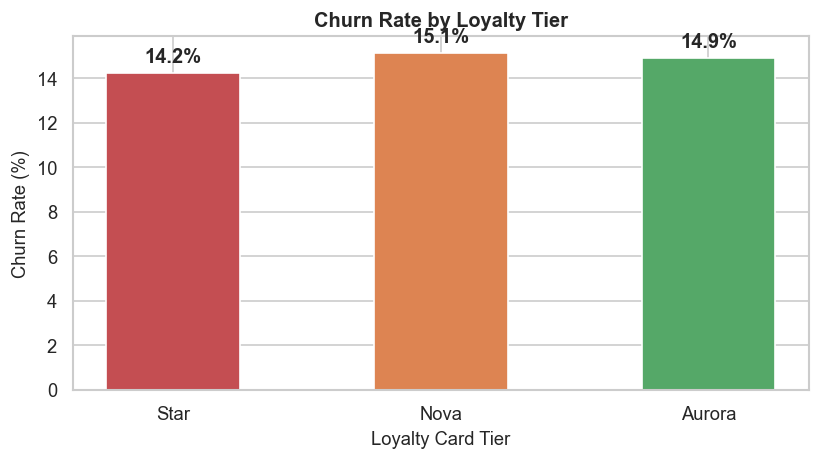

In [40]:
# 'Loyalty Card' is already in df
churn_by_tier = df.groupby('Loyalty Card')['Churn_Label'].mean() * 100
churn_by_tier = churn_by_tier.reindex(['Star','Nova','Aurora'])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(churn_by_tier.index, churn_by_tier.values,
 color=['#C44E52','#DD8452','#55A868'], edgecolor='white', width=0.5)
for bar, v in zip(bars, churn_by_tier.values):
 ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
 f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Churn Rate by Loyalty Tier', fontsize=12, fontweight='bold')
ax.set_xlabel('Loyalty Card Tier'); ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('plots/08_03_churn_by_tier.png', dpi=150)
plt.show()

### 8.6 - Save Churn-Enriched Dataset

In [41]:
df.to_csv('data/Customer_Master_Features_With_Churn.csv', index=False)
print(f"Saved: data/Customer_Master_Features_With_Churn.csv")
print(f"Shape: {df.shape}")
print(f"New columns added: Max_Inactive_Streak, Churn_Label")

Saved: data/Customer_Master_Features_With_Churn.csv
Shape: (16737, 27)
New columns added: Max_Inactive_Streak, Churn_Label



## SECTION 9 - K-Means Customer Segmentation
**Goal:** Group 16,737 customers into behavioral segments using K-Means clustering.
**Input:** `df_kmeans_input` -- pure behavioral features (no demographics, no CLV, no salary),

### 9.0 - Additional Imports

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df_ml = df_kmeans_input
print(f"K-Means input: {df_ml.shape[0]:,} customers x {df_ml.shape[1]} features")
print(f"Features: {df_ml.columns.tolist()}")

K-Means input: 16,737 customers x 8 features
Features: ['Total_Flights_2Yr', 'Points_Redeemed_2Yr', 'Customer_Tenure_Months', 'Months_Since_Last_Flight', 'Active_Months_Ratio', 'Holiday_Season_Flight_Ratio', 'Redemption_Rate', 'Dollar_Per_Redeemed_Point']



### 9.1 - StandardScaler: Normalize All Features


In [43]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_ml)

print(f" Scaled matrix shape: {scaled.shape}")
print(f" Mean - {scaled.mean():.4f} (should be ~0)")
print(f" Std - {scaled.std():.4f} (should be ~1)")
print(f"\nSample scaled row: {scaled[0].round(3)}")

 Scaled matrix shape: (16737, 8)
 Mean - 0.0000 (should be ~0)
 Std - 1.0000 (should be ~1)

Sample scaled row: [ 1.013  1.086 -0.436 -0.479  1.295  0.873  0.097  0.673]



### 9.2 - Elbow + Silhouette Scan (K = 2 to 10)
**What:** Run K-Means for each K and record two metrics:
- **WCSS (Inertia):** Sum of squared distances from each point to its cluster center. Lower = tighter clusters.
- **Silhouette Score:** How well-separated clusters are (0 = overlap, 1 = perfect). Higher = better.


In [44]:
k_range = range(2, 11)
wcss = []
sil_scores = []

print("Scanning K=2 to K=10...")
for k in k_range:
 km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
 km.fit(scaled)
 wcss.append(km.inertia_)
 sil_scores.append(silhouette_score(scaled, km.labels_))
 print(f" K={k} | WCSS: {km.inertia_:,.0f} | Silhouette: {sil_scores[-1]:.4f}")

print("\n Scan complete!")

Scanning K=2 to K=10...
 K=2 | WCSS: 88,296 | Silhouette: 0.4293
 K=3 | WCSS: 63,695 | Silhouette: 0.3890
 K=4 | WCSS: 53,690 | Silhouette: 0.3448
 K=5 | WCSS: 46,842 | Silhouette: 0.3636
 K=6 | WCSS: 40,982 | Silhouette: 0.3288
 K=7 | WCSS: 34,959 | Silhouette: 0.3281
 K=8 | WCSS: 31,279 | Silhouette: 0.3237
 K=9 | WCSS: 29,179 | Silhouette: 0.3127
 K=10 | WCSS: 27,105 | Silhouette: 0.3125

 Scan complete!



### 9.3 - Plot Elbow Curve
**What:** WCSS vs K -- look for where the curve bends.
**Why:** Before that bend, adding clusters significantly reduces inertia. After it, diminishing returns.

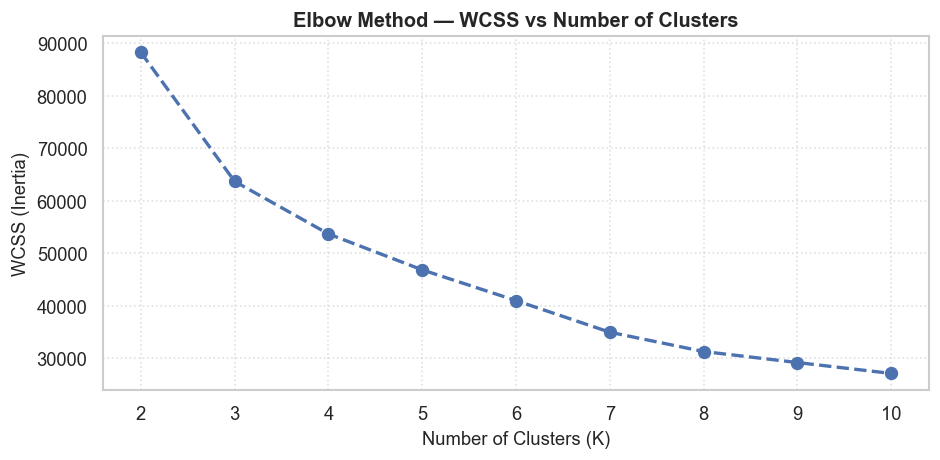

In [45]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, wcss, 'o--', color='#4C72B0', linewidth=2, markersize=7)
ax.set_title('Elbow Method — WCSS vs Number of Clusters', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('WCSS (Inertia)')
ax.set_xticks(k_range)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('plots/09_01_elbow_curve.png', dpi=150)
plt.show()


### 9.4 - Plot Silhouette Score
**What:** Silhouette score vs K.


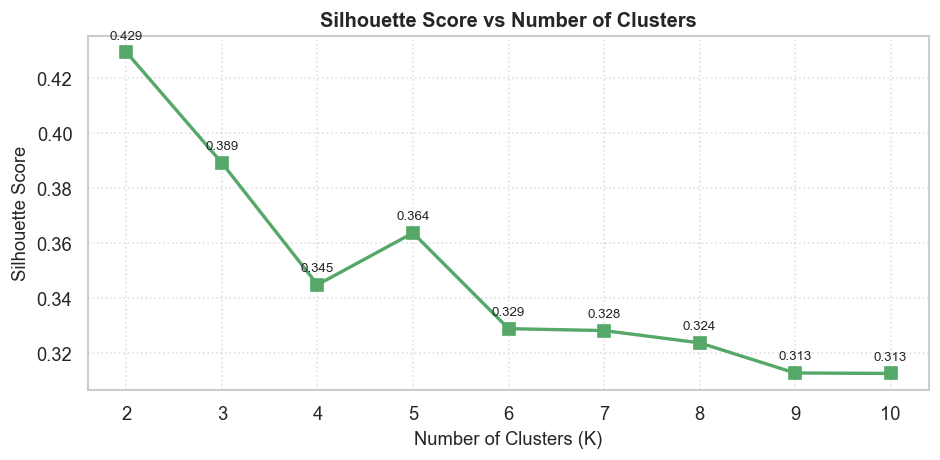

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, sil_scores, 's-', color='#55A868', linewidth=2, markersize=7)
for k, s in zip(k_range, sil_scores):
 ax.annotate(f'{s:.3f}', (k, s), textcoords='offset points',
 xytext=(0, 8), ha='center', fontsize=8)
ax.set_title('Silhouette Score vs Number of Clusters', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('Silhouette Score')
ax.set_xticks(k_range)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('plots/09_02_silhouette_curve.png', dpi=150)
plt.show()


### 9.5 - Fit Final K-Means with K=4


In [47]:
OPTIMAL_K = 4

final_km = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
cluster_labels = final_km.fit_predict(scaled)

df_ml['Cluster'] = cluster_labels
df['Cluster'] = cluster_labels

print(f"K-Means fitted with K={OPTIMAL_K}")
print("\nCluster sizes:")
for c, n in df['Cluster'].value_counts().sort_index().items():
 print(f" Cluster {c}: {n:,} customers ({n/len(df)*100:.1f}%)")

K-Means fitted with K=4

Cluster sizes:
 Cluster 0: 8,201 customers (49.0%)
 Cluster 1: 1,902 customers (11.4%)
 Cluster 2: 3,217 customers (19.2%)
 Cluster 3: 3,417 customers (20.4%)



### 9.6 - PCA Scatter: Visualize Clusters in 2D


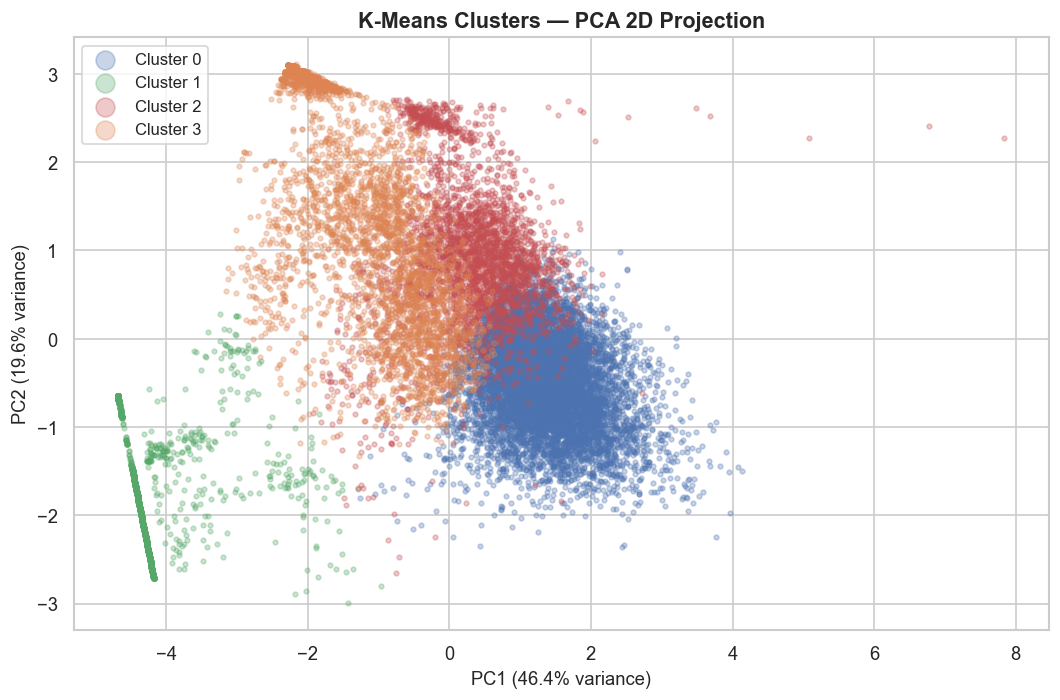

Total variance explained by 2 PCs: 66.0%


In [48]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled)
var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#4C72B0','#55A868','#C44E52','#DD8452']

for c in range(OPTIMAL_K):
 mask = cluster_labels == c
 ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
 alpha=0.3, s=8, color=colors[c], label=f'Cluster {c}')

ax.set_title('K-Means Clusters — PCA 2D Projection', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
ax.legend(markerscale=4, fontsize=10)
plt.tight_layout()
plt.savefig('plots/09_03_pca_clusters.png', dpi=150)
plt.show()
print(f"Total variance explained by 2 PCs: {sum(var_explained):.1f}%")

~1,650 customers (about 10% of your base) have done literally nothing since joining — zero flights, zero redemptions, zero seasonal activity, ever. The only variable about them is enrollment date.

### 9.7 - Save Segmented Dataset

In [49]:
df.to_csv('data/Customer_Master_Segmented.csv', index=False)
print(f"Saved: data/Customer_Master_Segmented.csv -- Shape: {df.shape}")

Saved: data/Customer_Master_Segmented.csv -- Shape: (16737, 28)



## SECTION 10 - Segment Profiling and Naming


### 10.0 - Add Demographic Columns
`df` already contains all behavioral features, churn label, and cluster assignment. We merge in the remaining demographic columns needed for profiling.

In [50]:
df = df.merge(df_loyalty[['Loyalty Number','Gender','Marital Status','Province']],
 on='Loyalty Number', how='left')
print(f"Shape: {df.shape}")

Shape: (16737, 31)



### 10.1 - Behavioral Profile Table per Cluster


In [51]:
profile_cols = ['Total_Flights_2Yr','Total_Distance_2Yr','CLV','Salary',
 'Active_Months_Ratio','Months_Since_Last_Flight',
 'Redemption_Rate','Customer_Tenure_Months','Churn_Label']

profile = df.groupby('Cluster')[profile_cols].mean().round(2)
profile['Size'] = df['Cluster'].value_counts().sort_index()

print("Behavioral Profile per Cluster (read columns to compare):")
display(profile.T)

Behavioral Profile per Cluster (read columns to compare):


Cluster,0,1,2,3
Total_Flights_2Yr,39.41,1.38,26.67,26.06
Total_Distance_2Yr,58993.30,2084.81,39942.60,39101.64
CLV,7594.89,7781.72,7417.99,7472.67
Salary,56283.08,56629.77,54083.19,54976.70
Active_Months_Ratio,0.61,0.02,0.35,0.35
Months_Since_Last_Flight,0.73,23.91,1.62,1.32
Redemption_Rate,0.02,0.00,0.03,0.00
Customer_Tenure_Months,51.76,40.77,16.36,25.24
Churn_Label,0.01,1.00,0.08,0.06
Size,8201.00,1902.00,3217.00,3417.00



### 10.2 - Assign Segment Names


In [52]:
segment_names = {
    0: 'Champions',                # highest flights, lowest churn (0.01)
    1: 'Dormant',                   # near-zero flights, highest churn (1.00)
    2: 'At-Risk',                   # higher churn (0.08) of the two middle clusters
    3: 'Loyalists'                  # lower churn (0.06), longer tenure, higher CLV
}

df['Segment_Name'] = df['Cluster'].map(segment_names)

print("Cluster -> Segment Name mapping:")
for cid, name in segment_names.items():
    size = (df['Cluster'] == cid).sum()
    print(f"  Cluster {cid} -> {name} ({size:,} customers)")

Cluster -> Segment Name mapping:
  Cluster 0 -> Champions (8,201 customers)
  Cluster 1 -> Dormant (1,902 customers)
  Cluster 2 -> At-Risk (3,217 customers)
  Cluster 3 -> Loyalists (3,417 customers)



### 10.3 - Segment Size Donut Chart


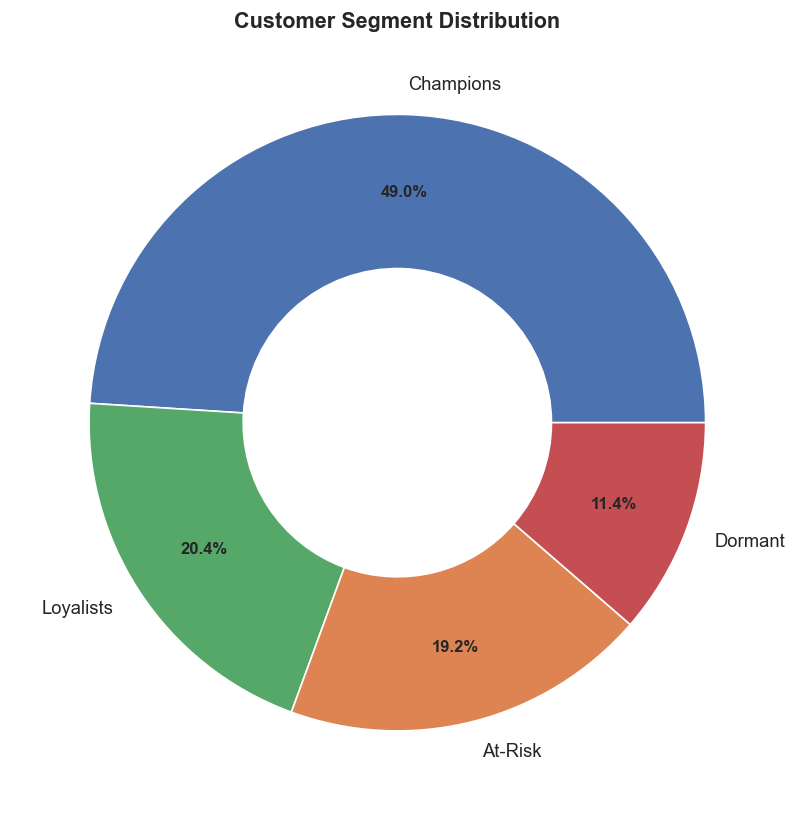

In [53]:
seg_counts = df['Segment_Name'].value_counts()
colors = ['#4C72B0','#55A868','#DD8452','#C44E52']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
 seg_counts.values, labels=seg_counts.index,
 autopct='%1.1f%%', colors=colors, pctdistance=0.75,
 wedgeprops=dict(width=0.5) # donut hole
)
for t in autotexts:
 t.set_fontsize(10); t.set_fontweight('bold')
ax.set_title('Customer Segment Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/10_01_segment_donut.png', dpi=150)
plt.show()


### 10.4 - Radar Chart: Behavioral Fingerprint per Segment


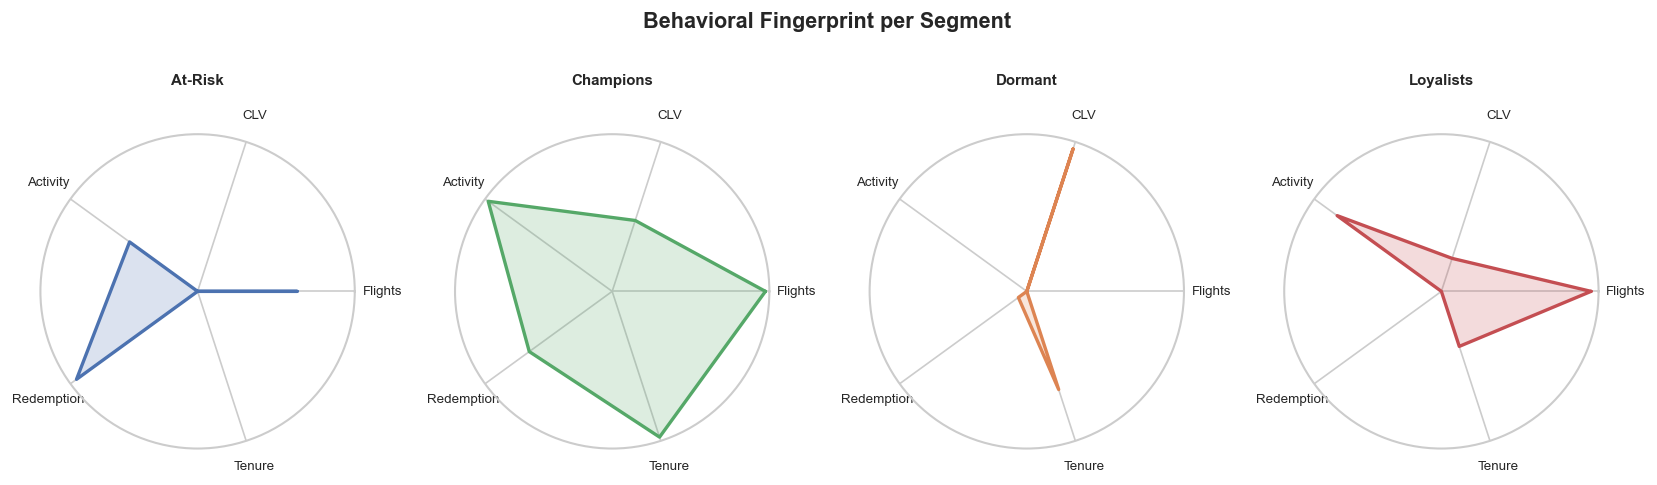

In [54]:
radar_cols = ['Total_Flights_2Yr','CLV','Active_Months_Ratio',
 'Redemption_Rate','Customer_Tenure_Months']
radar_labels = ['Flights','CLV','Activity','Redemption','Tenure']

radar_data = df.groupby('Segment_Name')[radar_cols].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N = len(radar_cols)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

seg_list = radar_norm.index.tolist()
colors = ['#4C72B0','#55A868','#DD8452','#C44E52']

fig, axes = plt.subplots(1, len(seg_list), figsize=(14, 4), subplot_kw=dict(polar=True))
for ax, seg, color in zip(axes, seg_list, colors):
 vals = radar_norm.loc[seg].tolist() + radar_norm.loc[seg].tolist()[:1]
 ax.plot(angles, vals, color=color, linewidth=2)
 ax.fill(angles, vals, alpha=0.2, color=color)
 ax.set_xticks(angles[:-1])
 ax.set_xticklabels(radar_labels, fontsize=8)
 ax.set_yticks([])
 ax.set_title(seg, fontsize=9, fontweight='bold', pad=15)

plt.suptitle('Behavioral Fingerprint per Segment', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/10_02_radar_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


### 10.5 - Loyalty Tier Composition per Segment


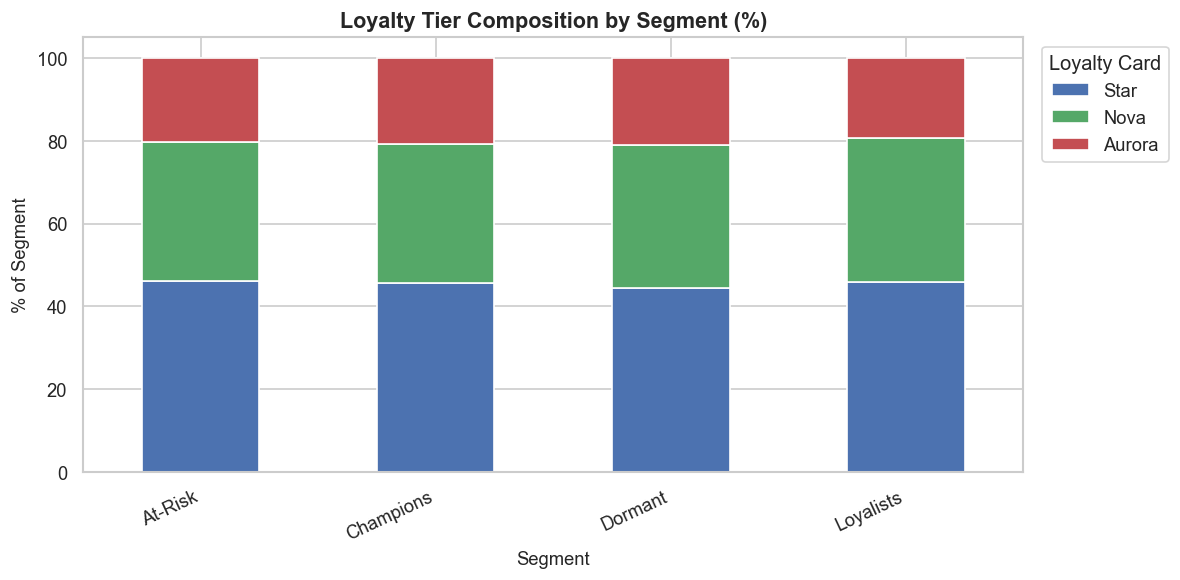

In [55]:
if 'Loyalty Card' not in df.columns:
    df = df.merge(df_loyalty[['Loyalty Number','Loyalty Card']], on='Loyalty Number', how='left')

tier_seg = pd.crosstab(df['Segment_Name'], df['Loyalty Card'], normalize='index') * 100
tier_order = [c for c in ['Star','Nova','Aurora'] if c in tier_seg.columns]
tier_seg = tier_seg[tier_order]

fig, ax = plt.subplots(figsize=(10, 5))
tier_seg.plot(kind='bar', stacked=True, ax=ax,
 color=['#4C72B0','#55A868','#C44E52'], edgecolor='white')
ax.set_title('Loyalty Tier Composition by Segment (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Segment'); ax.set_ylabel('% of Segment')
ax.legend(title='Loyalty Card', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('plots/10_03_tier_by_segment.png', dpi=150)
plt.show()

"Formal loyalty tier (Star/Nova/Aurora) shows no meaningful correlation with behavioral segment. A customer's tier reflects historical spend thresholds, not current engagement.


### 10.6 - CLV and Salary by Segment (Economic Value Overlay)


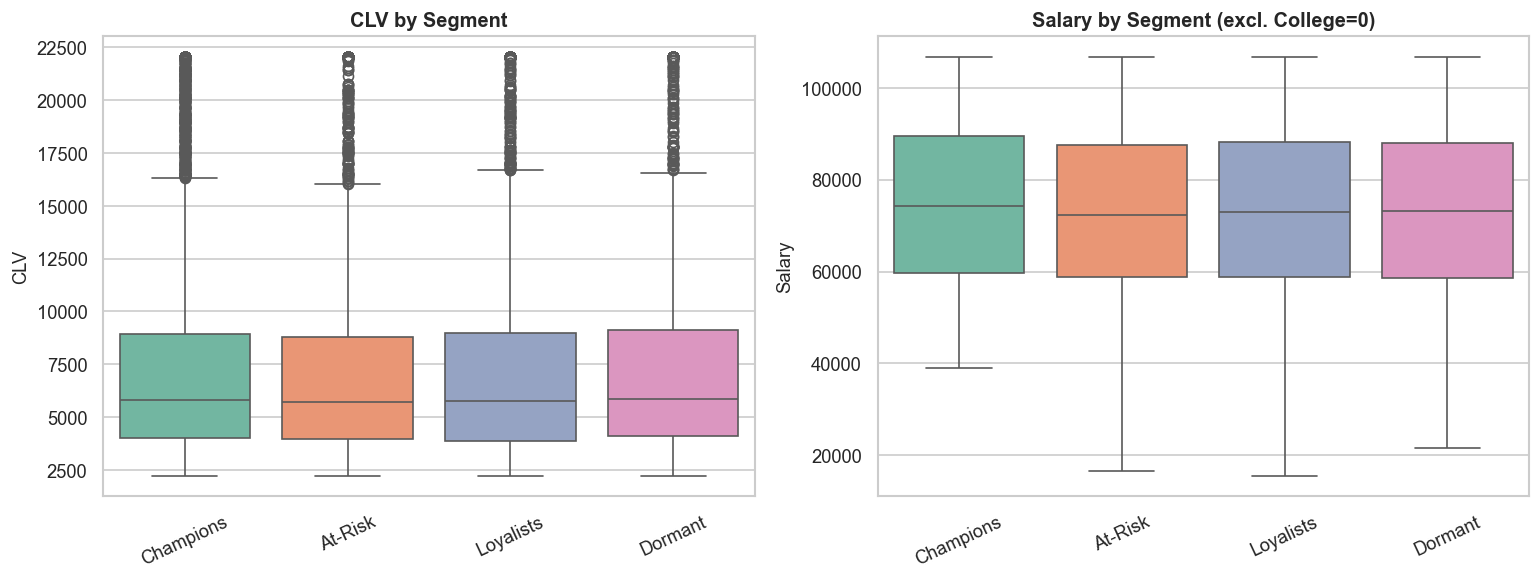

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Segment_Name', y='CLV', ax=ax1, palette='Set2')
ax1.set_title('CLV by Segment', fontsize=12, fontweight='bold')
ax1.set_xlabel(''); ax1.tick_params(axis='x', rotation=25)

sns.boxplot(data=df[df['Salary'] > 0], x='Segment_Name', y='Salary', ax=ax2, palette='Set2')
ax2.set_title('Salary by Segment (excl. College=0)', fontsize=12, fontweight='bold')
ax2.set_xlabel(''); ax2.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('plots/10_04_clv_salary_by_segment.png', dpi=150)
plt.show()

### 10.7 -- Save Final Profiled Dataset

In [57]:
df.to_csv('data/Customer_Final_Profiled.csv', index=False)
print(f"Saved: data/Customer_Final_Profiled.csv -- Shape: {df.shape}")
print("\nFinal segment summary:")
print(df.groupby('Segment_Name')[['CLV','Total_Flights_2Yr','Churn_Label']].mean().round(2))

Saved: data/Customer_Final_Profiled.csv -- Shape: (16737, 32)

Final segment summary:
                  CLV  Total_Flights_2Yr  Churn_Label
Segment_Name                                         
At-Risk       7417.99              26.67         0.08
Champions     7594.89              39.41         0.01
Dormant       7781.72               1.38         1.00
Loyalists     7472.67              26.06         0.06



## SECTION 11 - Churn Prediction Model
**Goal:** Predict which individual customers will churn -- and WHY.


In [58]:
# Time-based split: months 1-18 = observation window, months 19-24 = outcome window
# Jan 2017 = month 1 ... Dec 2018 = month 24
df_combined['month_index'] = (df_combined['Year'] - 2017) * 12 + df_combined['Month']

df_obs     = df_combined[df_combined['month_index'] <= 18].copy()   # Jan 2017 - Jun 2018
df_outcome = df_combined[df_combined['month_index'] >  18].copy()   # Jul 2018 - Dec 2018

print(f"Observation window: {df_obs['month_index'].min()}-{df_obs['month_index'].max()} ({df_obs.shape[0]:,} rows)")
print(f"Outcome window    : {df_outcome['month_index'].min()}-{df_outcome['month_index'].max()} ({df_outcome.shape[0]:,} rows)")

Observation window: 1-18 (288,643 rows)
Outcome window    : 19-24 (100,422 rows)


In [59]:
# A customer is "future churned" if ALL 6 months in the outcome window are inactive
df_outcome['is_inactive'] = (
    (df_outcome['Total Flights'] == 0) & (df_outcome['Points Redeemed'] == 0)
).astype(int)

# Count inactive months per customer in the outcome window (max possible = 6)
outcome_inactive = df_outcome.groupby('Loyalty Number')['is_inactive'].sum().reset_index()
outcome_inactive.columns = ['Loyalty Number', 'Inactive_Months_Last6']

# Churn label: inactive for all 6 of the last 6 months
outcome_inactive['Churn_Label'] = (outcome_inactive['Inactive_Months_Last6'] == 6).astype(int)

print(outcome_inactive['Churn_Label'].value_counts())
print(f"Churn rate: {outcome_inactive['Churn_Label'].mean()*100:.1f}%")

Churn_Label
0    14282
1     2455
Name: count, dtype: int64
Churn rate: 14.7%


In [60]:
# --- Customer-grain aggregation from observation window only ---
df_obs_base = df_obs.groupby('Loyalty Number').agg({
    'Total Flights'               : 'sum',
    'Distance'                    : 'sum',
    'Points Accumulated'          : 'sum',
    'Points Redeemed'             : 'sum',
}).reset_index()
df_obs_base.rename(columns={
    'Total Flights'      : 'Total_Flights_18mo',
    'Distance'           : 'Total_Distance_18mo',
    'Points Accumulated' : 'Points_Accumulated_18mo',
    'Points Redeemed'    : 'Points_Redeemed_18mo'
}, inplace=True)

# Active months ratio (out of 18)
df_obs['Is_Active'] = (df_obs['Total Flights'] > 0).astype(int)
active_18 = df_obs.groupby('Loyalty Number')['Is_Active'].sum().reset_index()
df_obs_base = df_obs_base.merge(active_18, on='Loyalty Number', how='left')
df_obs_base['Active_Months_Ratio_18mo'] = df_obs_base['Is_Active'] / 18.0
df_obs_base.drop(columns=['Is_Active'], inplace=True)

# Redemption rate
df_obs_base['Redemption_Rate_18mo'] = np.where(
    df_obs_base['Points_Accumulated_18mo'] > 0,
    df_obs_base['Points_Redeemed_18mo'] / df_obs_base['Points_Accumulated_18mo'],
    0.0
)

# Max inactivity streak within the 18-month window
df_streak18 = df_obs.sort_values(['Loyalty Number','month_index']).copy()
df_streak18['is_inactive'] = (
    (df_streak18['Total Flights'] == 0) & (df_streak18['Points Redeemed'] == 0)
).astype(int)

def max_streak(series):
    max_s, cur = 0, 0
    for v in series:
        cur = cur + 1 if v == 1 else 0
        max_s = max(max_s, cur)
    return max_s

streak18 = df_streak18.groupby('Loyalty Number')['is_inactive'].apply(max_streak).reset_index()
streak18.columns = ['Loyalty Number', 'Max_Inactivity_Streak_18mo']
df_obs_base = df_obs_base.merge(streak18, on='Loyalty Number', how='left')

print(f"18-month feature set: {df_obs_base.shape}")
df_obs_base.head(3)

18-month feature set: (16737, 8)


,Loyalty Number,Total_Flights_18mo,Total_Distance_18mo,Points_Accumulated_18mo,Points_Redeemed_18mo,Active_Months_Ratio_18mo,Redemption_Rate_18mo,Max_Inactivity_Streak_18mo
0,100018,29,44813,44813.0,1128,0.722222,0.025171,2
1,100102,34,50123,50123.0,1195,0.666667,0.023841,3
2,100140,36,52368,52368.0,593,0.722222,0.011324,1


In [61]:
# df_features_capped already has demographics, tenure, salary, CLV, etc (these are time-independent)
demo_cols = ['Loyalty Number','Customer_Tenure_Months','Is_Salary_Unknown','Salary','CLV',
              'Education','Marital Status','Gender','Province','Enrollment Type','Loyalty Card']

df_model = df_obs_base.merge(df_features_capped[demo_cols], on='Loyalty Number', how='left')
df_model = df_model.merge(outcome_inactive[['Loyalty Number','Churn_Label']], on='Loyalty Number', how='left')

# Customers with no rows in outcome window (shouldn't happen, but safety check)
df_model['Churn_Label'] = df_model['Churn_Label'].fillna(0).astype(int)

print(f"Final modeling dataset: {df_model.shape}")
print(df_model['Churn_Label'].value_counts())

Final modeling dataset: (16737, 19)
Churn_Label
0    14282
1     2455
Name: count, dtype: int64


### 11.0 - Additional Imports

In [62]:
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
 ConfusionMatrixDisplay, roc_curve)

print(f"Working dataset: {df_model.shape}")
print(f"Churn rate: {df_model['Churn_Label'].mean()*100:.1f}%")

Working dataset: (16737, 19)
Churn rate: 14.7%



### 11.1 - Prepare Features and Target


In [63]:
TARGET = 'Churn_Label'

leak_cols = ['Loyalty Number', 'Churn_Label', 'Months_Since_Last_Flight',
             'Max_Inactivity_Streak', 'Active_Months_Ratio']
drop_cols = [c for c in leak_cols if c in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model[TARGET]

cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f'Feature matrix: {X.shape}')
print(f'Target: {y.value_counts().to_dict()}')


Feature matrix: (16737, 31)
Target: {0: 14282, 1: 2455}



### 11.2 - Train / Test Split


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]:,} | Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test : {X_test.shape[0]:,} | Churn rate: {y_test.mean()*100:.1f}%")

Train : 13,389 | Churn rate: 14.7%
Test : 3,348 | Churn rate: 14.7%



### 11.3 - Train GradientBoosting



In [65]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
best_model.fit(X_train, y_train, sample_weight=sample_weights)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
print(f"Class weight ratio (neg/pos): {neg/pos:.2f}")
print("Gradient Boosting trained!")

Class weight ratio (neg/pos): 5.82
Gradient Boosting trained!


              Model    AUC  F1-Churn  Recall
  Gradient Boosting 0.9565    0.8065  0.8065
      Random Forest 0.9505    0.8343  0.8343
            XGBoost 0.9504    0.8152  0.8152
Logistic Regression 0.8982    0.6457  0.6457


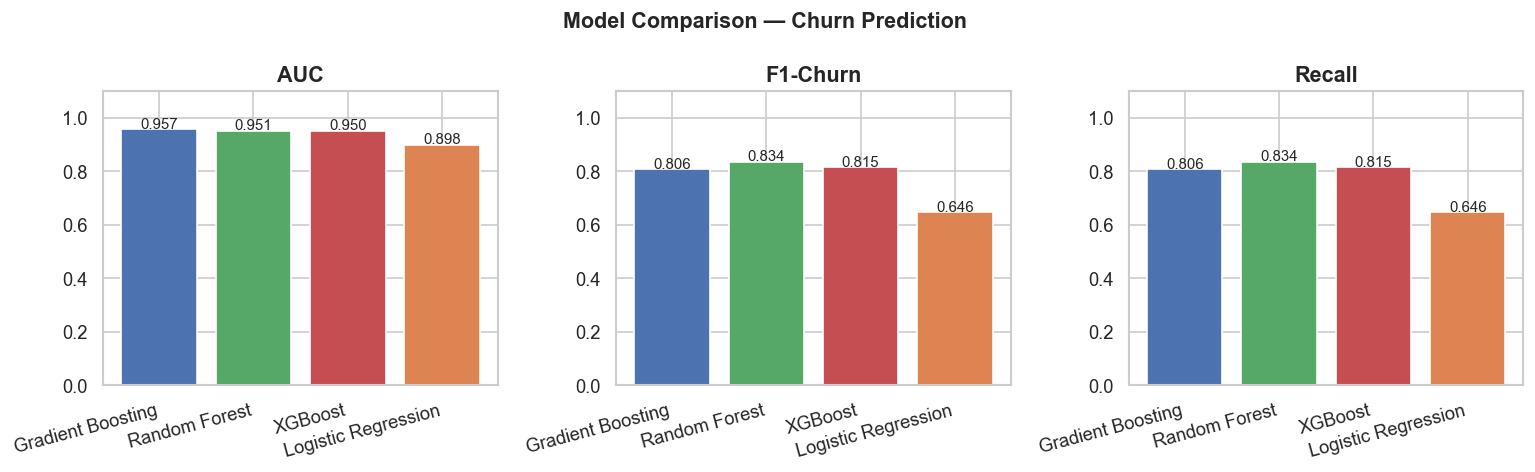

Selected: Gradient Boosting | AUC: 0.9565


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

candidates = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : best_model,
    'XGBoost'             : XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                          scale_pos_weight=scale_weight,
                                          random_state=42, eval_metric='logloss', verbosity=0)
}

results = []
for name, model in candidates.items():
    if name != 'Gradient Boosting':
        model.fit(X_train, y_train)
    yp  = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model'    : name,
        'AUC'      : round(roc_auc_score(y_test, ypr), 4),
        'F1-Churn' : round(f1_score(y_test, yp), 4),
        'Recall'   : round(f1_score(y_test, yp, average=None)[1], 4)
    })

df_results = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#4C72B0','#55A868','#C44E52','#DD8452']
for ax, metric in zip(axes, ['AUC','F1-Churn','Recall']):
    bars = ax.bar(df_results['Model'], df_results[metric], color=colors, edgecolor='white')
    for bar, v in zip(bars, df_results[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(df_results['Model'], rotation=15, ha='right')
plt.suptitle('Model Comparison — Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_model_comparison.png', dpi=150)
plt.show()
print(f'Selected: Gradient Boosting | AUC: {df_results[df_results["Model"]=="Gradient Boosting"]["AUC"].values[0]}')


### 11.4 - Evaluate: Classification Report


In [68]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Churned','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


              precision    recall  f1-score   support

 Not Churned       0.98      0.95      0.96      2857
     Churned       0.76      0.86      0.81       491

    accuracy                           0.94      3348
   macro avg       0.87      0.91      0.89      3348
weighted avg       0.94      0.94      0.94      3348

ROC-AUC: 0.9565



### 11.5 - Confusion Matrix


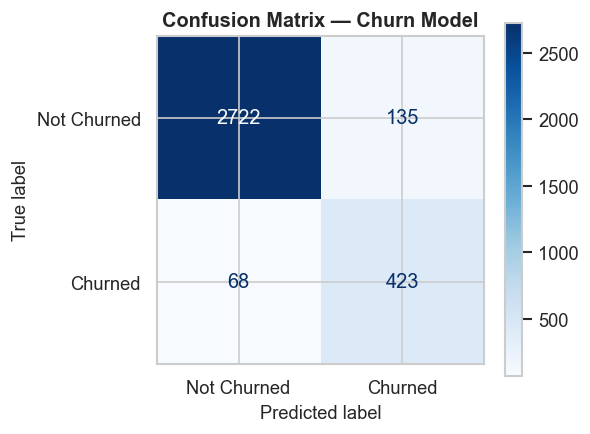

In [69]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
 y_test, y_pred,
 display_labels=['Not Churned','Churned'],
 cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Churn Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_01_confusion_matrix.png', dpi=150)
plt.show()


### 11.6 - ROC Curve


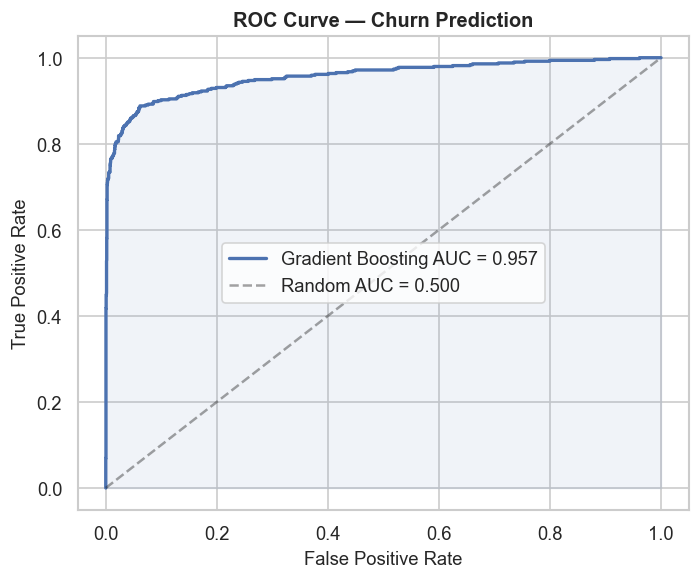

In [70]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'Gradient Boosting AUC = {auc:.3f}')
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random AUC = 0.500')
ax.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
ax.set_title('ROC Curve — Churn Prediction', fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('plots/11_02_roc_curve.png', dpi=150)
plt.show()


### 11.7 - SHAP: Which Features Drive Churn


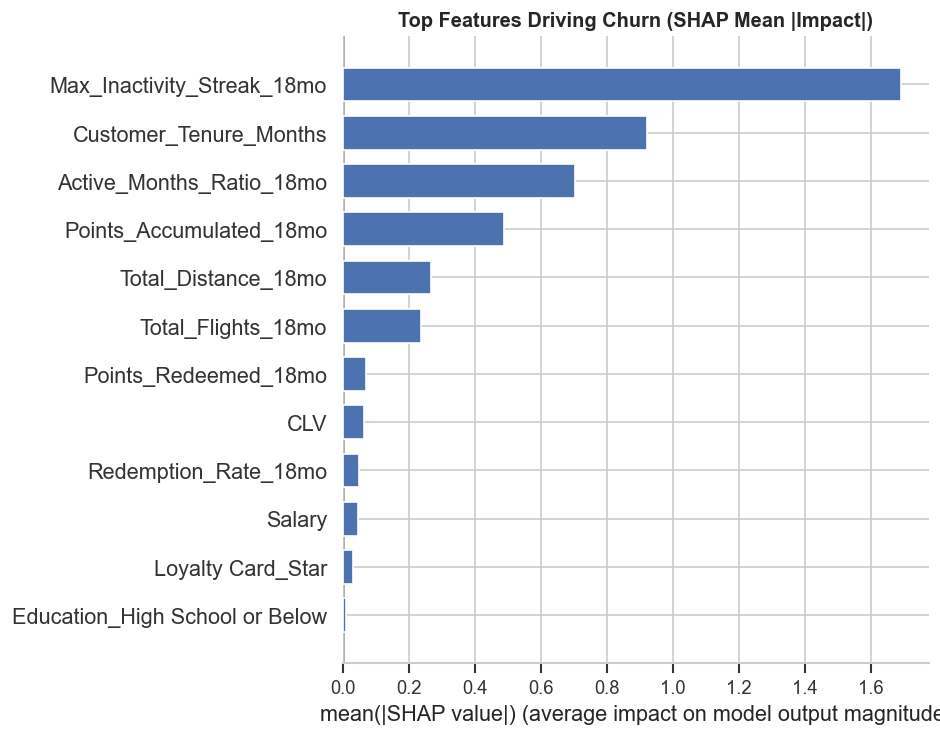

In [71]:

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar',
 show=False, max_display=12, color='#4C72B0')
plt.title('Top Features Driving Churn (SHAP Mean |Impact|)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_03_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


### 11.8 - SHAP Beeswarm: Direction of Impact


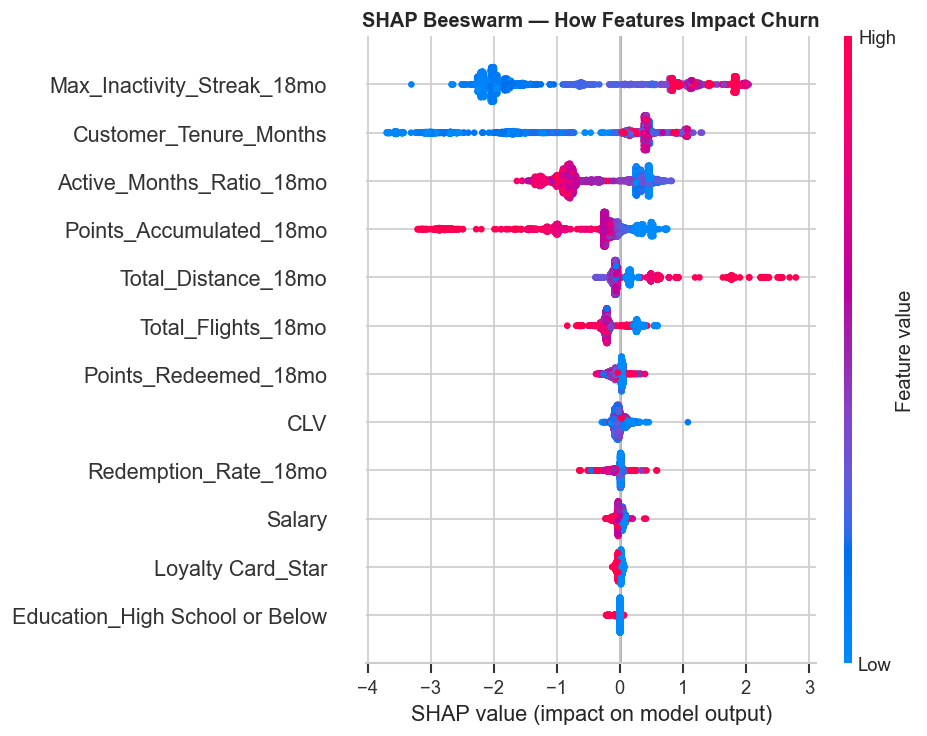

In [72]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, show=False, max_display=12)
plt.title('SHAP Beeswarm — How Features Impact Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_04_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


### 11.9 - Attach Churn Probability to Master Dataset


In [73]:
# Attach probability/risk to df_model first (the 18mo modeling dataset)
# Churn probability cell
df_model['Churn_Probability'] = best_model.predict_proba(X)[:, 1]
df_model['Churn_Risk_Tier'] = pd.cut(df_model['Churn_Probability'],
                                      bins=[0, 0.3, 0.6, 1.0],
                                      labels=['Low Risk','Medium Risk','High Risk'])

# Merge into df (which has Segment_Name from Section 10) by Loyalty Number
df = df.merge(df_model[['Loyalty Number','Churn_Probability','Churn_Risk_Tier']],
               on='Loyalty Number', how='left')

df.to_csv('data/Customer_Final_With_ChurnRisk.csv', index=False)
print("Saved: data/Customer_Final_With_ChurnRisk.csv")
print("\nChurn Risk Distribution:")
print(df['Churn_Risk_Tier'].value_counts())

Saved: data/Customer_Final_With_ChurnRisk.csv

Churn Risk Distribution:
Churn_Risk_Tier
Low Risk       12590
High Risk       2442
Medium Risk     1705
Name: count, dtype: int64



## SECTION 12 - Retention Recommendations (Segment x Risk Matrix)


### 12.0 - Working Dataset

In [74]:
print(f"Shape: {df.shape}")
print(df[['Segment_Name','Churn_Risk_Tier','Churn_Probability']].head(3))

Shape: (16737, 34)
  Segment_Name Churn_Risk_Tier  Churn_Probability
0    Champions        Low Risk           0.057621
1    Champions        Low Risk           0.051160
2    Champions        Low Risk           0.077741



### 12.1 - Segment x Churn Risk Matrix (Customer Counts)


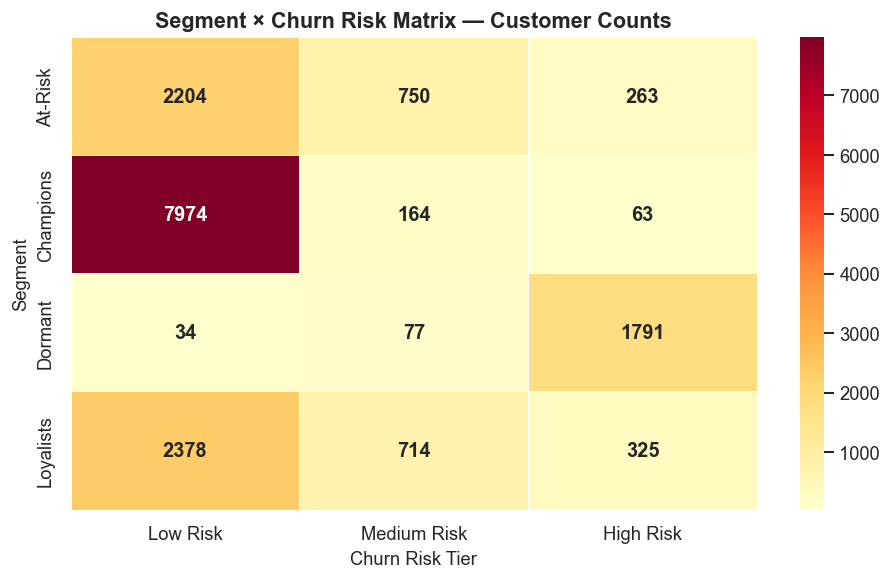

In [75]:
matrix = pd.crosstab(df['Segment_Name'], df['Churn_Risk_Tier'])
risk_order = [r for r in ['Low Risk','Medium Risk','High Risk'] if r in matrix.columns]
matrix = matrix[risk_order]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd',
 linewidths=0.5, ax=ax, annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Segment × Churn Risk Matrix — Customer Counts', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Risk Tier'); ax.set_ylabel('Segment')
plt.tight_layout()
plt.savefig('plots/12_01_segment_risk_heatmap.png', dpi=150)
plt.show()


### 12.2 - Average Churn Probability by Segment
**What:** Bar chart of mean churn probability per segment.
**Why:** Determines budget allocation -- segments with higher avg risk need larger retention budgets.

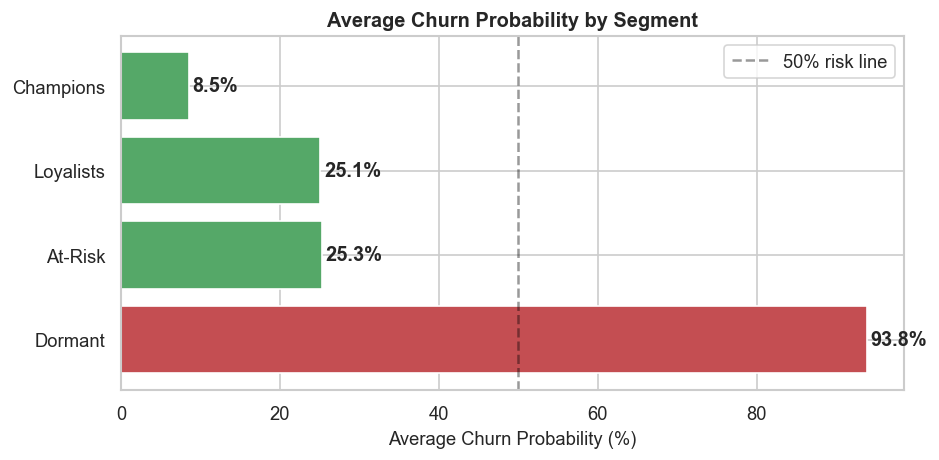

In [76]:
seg_risk = df.groupby('Segment_Name')['Churn_Probability'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52' if v > 0.5 else '#DD8452' if v > 0.3 else '#55A868'
 for v in seg_risk.values]
bars = ax.barh(seg_risk.index, seg_risk.values * 100, color=colors, edgecolor='white')
for bar, v in zip(bars, seg_risk.values):
 ax.text(v * 100 + 0.5, bar.get_y() + bar.get_height()/2,
 f'{v*100:.1f}%', va='center', fontweight='bold')
ax.axvline(50, color='black', linestyle='--', alpha=0.4, label='50% risk line')
ax.set_title('Average Churn Probability by Segment', fontsize=12, fontweight='bold')
ax.set_xlabel('Average Churn Probability (%)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/12_02_churn_prob_by_segment.png', dpi=150)
plt.show()


### 12.3 - CLV at Stake: Revenue Risk by Segment
**What:** Total CLV of high-risk customers in each segment.


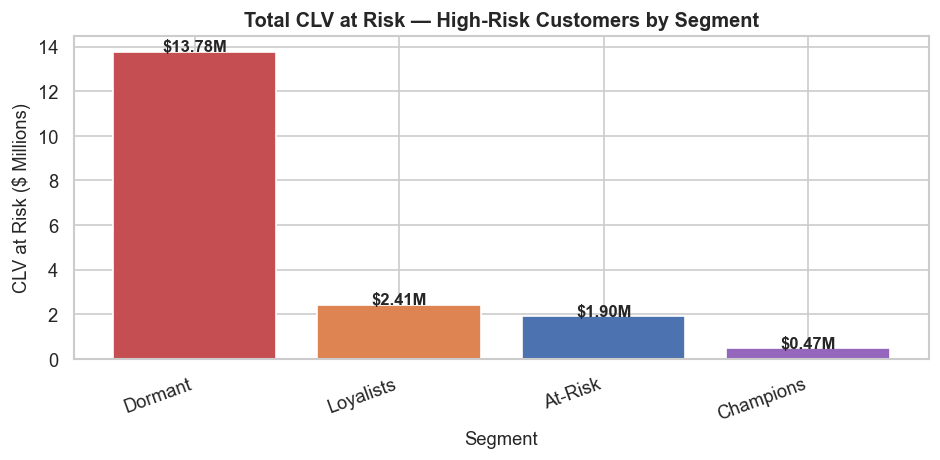


 Total CLV at Risk (all High-Risk customers): $18,562,364


In [77]:
high_risk = df[df['Churn_Risk_Tier'] == 'High Risk']
clv_at_risk = high_risk.groupby('Segment_Name')['CLV'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52','#DD8452','#4C72B0','#9467BD']
bars = ax.bar(clv_at_risk.index, clv_at_risk.values / 1e6,
 color=colors[:len(clv_at_risk)], edgecolor='white')
for bar, v in zip(bars, clv_at_risk.values):
 ax.text(bar.get_x() + bar.get_width()/2, v/1e6 + 0.02,
 f'${v/1e6:.2f}M', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Total CLV at Risk — High-Risk Customers by Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('CLV at Risk ($ Millions)'); ax.set_xlabel('Segment')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plots/12_03_clv_at_risk.png', dpi=150)
plt.show()
print(f"\n Total CLV at Risk (all High-Risk customers): ${high_risk['CLV'].sum():,.0f}")


### 12.4 - Retention Action Playbook
**What:** 12-cell action table -- one specific action per Segment x Risk combination.
**Why specific?** Vague recommendations ("send bonus points") are ignored. Specific recommendations ("dedicated agent call within 48 hours plus tier fast-track offer") get executed.
**The CFO/CMO test:** Every action includes WHO receives it, WHEN, WHY, and in WHAT FORM.

In [78]:
playbook = pd.DataFrame([
 # Champions
 {'Segment':'Champions','Risk':'High Risk',
 'Action':'Dedicated agent call within 48h + tier fast-track + exclusive route preview',
 'Priority':'CRITICAL','Budget':'High'},
 {'Segment':'Champions','Risk':'Medium Risk',
 'Action':'Personalised email + 3× points on next 3 bookings + lounge upgrade',
 'Priority':'HIGH','Budget':'High'},
 {'Segment':'Champions','Risk':'Low Risk',
 'Action':'Quarterly appreciation gift + early access to new routes — maintain relationship',
 'Priority':'MAINTAIN','Budget':'Medium'},
 # Loyalists
 {'Segment':'Loyalists','Risk':'High Risk',
 'Action':'Double points for 45 days + show Champions tier benefits (upsell path)',
 'Priority':'HIGH','Budget':'Medium'},
 {'Segment':'Loyalists','Risk':'Medium Risk',
 'Action':'Email series: "You are X points from Nova tier" — gamified progress nudge',
 'Priority':'MEDIUM','Budget':'Medium'},
 {'Segment':'Loyalists','Risk':'Low Risk',
 'Action':'Monthly newsletter + seasonal destination deals + redemption reminders',
 'Priority':'MAINTAIN','Budget':'Low'},
 # At-Risk
 {'Segment':'At-Risk','Risk':'High Risk',
 'Action':'"We miss you" SMS + email: 500 bonus points just for logging in, valid 30 days',
 'Priority':'HIGH','Budget':'Medium'},
 {'Segment':'At-Risk','Risk':'Medium Risk',
 'Action':'Survey: "What would bring you back?" + $10 flight credit on completion',
 'Priority':'MEDIUM','Budget':'Low'},
 {'Segment':'At-Risk','Risk':'Low Risk',
 'Action':'Points expiry reminder + easy redemption offer via push notification',
 'Priority':'MONITOR','Budget':'Low'},
 # Dormant
 {'Segment':'Dormant','Risk':'High Risk',
 'Action':'Final re-engagement: "Your points expire in 30 days" + steep discount offer',
 'Priority':'LAST CHANCE','Budget':'Low'},
 {'Segment':'Dormant','Risk':'Medium Risk',
 'Action':'Automated low-cost email: simple redemption opportunity, one-click booking',
 'Priority':'LOW','Budget':'Minimal'},
 {'Segment':'Dormant','Risk':'Low Risk',
 'Action':'Sunset — flag for program removal to cut dead-weight operational cost',
 'Priority':'SUNSET','Budget':'None'},
])

pd.set_option('display.max_colwidth', 85)
print(playbook.to_string(index=False))

  Segment        Risk                                                                           Action    Priority  Budget
Champions   High Risk      Dedicated agent call within 48h + tier fast-track + exclusive route preview    CRITICAL    High
Champions Medium Risk               Personalised email + 3× points on next 3 bookings + lounge upgrade        HIGH    High
Champions    Low Risk Quarterly appreciation gift + early access to new routes — maintain relationship    MAINTAIN  Medium
Loyalists   High Risk           Double points for 45 days + show Champions tier benefits (upsell path)        HIGH  Medium
Loyalists Medium Risk        Email series: "You are X points from Nova tier" — gamified progress nudge      MEDIUM  Medium
Loyalists    Low Risk           Monthly newsletter + seasonal destination deals + redemption reminders    MAINTAIN     Low
  At-Risk   High Risk   "We miss you" SMS + email: 500 bonus points just for logging in, valid 30 days        HIGH  Medium
  At-Risk Medium


### 12.5 - Percent of Customer Base per Action Cell
**What:** Heatmap showing what % of the total customer base falls into each cell.
**Why %?** Counts tell you volume; % tells you relative priority. A cell with 0.5% of customers that has Champions x High Risk outweighs a cell with 5% of Dormant x Low Risk.

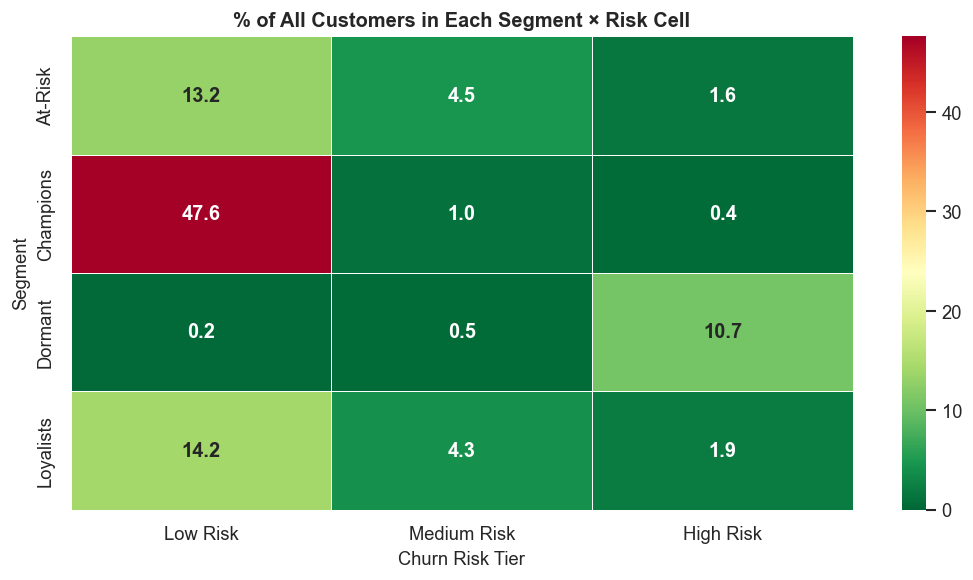

In [79]:
matrix_pct = pd.crosstab(df['Segment_Name'], df['Churn_Risk_Tier'],
 normalize='all') * 100
risk_order = [r for r in ['Low Risk','Medium Risk','High Risk'] if r in matrix_pct.columns]
matrix_pct = matrix_pct[risk_order]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(matrix_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
 linewidths=0.5, ax=ax, annot_kws={'size': 12, 'weight': 'bold'},
 vmin=0, vmax=matrix_pct.values.max())
ax.set_title('% of All Customers in Each Segment × Risk Cell', fontsize=12, fontweight='bold')
ax.set_xlabel('Churn Risk Tier'); ax.set_ylabel('Segment')
plt.tight_layout()
plt.savefig('plots/12_04_priority_matrix_pct.png', dpi=150)
plt.show()

### 12.6 -- Export Final Action Plan Dataset

In [80]:
df_final = df.merge(
 playbook.rename(columns={'Segment':'Segment_Name','Risk':'Churn_Risk_Tier'}),
 on=['Segment_Name','Churn_Risk_Tier'], how='left'
)
df_final.to_csv('data/Customer_Retention_Action_Plan.csv', index=False)
print(f"Saved: data/Customer_Retention_Action_Plan.csv")
print(f"Shape: {df_final.shape}")
print("\nSample output:")
display(df_final[['Loyalty Number','Segment_Name','Churn_Risk_Tier',
 'Churn_Probability','Action','Priority']].head(6))

Saved: data/Customer_Retention_Action_Plan.csv
Shape: (16737, 37)

Sample output:


,Loyalty Number,Segment_Name,Churn_Risk_Tier,Churn_Probability,Action,Priority
0,100018,Champions,Low Risk,0.057621,Quarterly appreciation gift + early access to new routes — maintain relationship,MAINTAIN
1,100102,Champions,Low Risk,0.051160,Quarterly appreciation gift + early access to new routes — maintain relationship,MAINTAIN
2,100140,Champions,Low Risk,0.077741,Quarterly appreciation gift + early access to new routes — maintain relationship,MAINTAIN
3,100214,At-Risk,Low Risk,0.143790,Points expiry reminder + easy redemption offer via push notification,MONITOR
4,100272,Champions,Low Risk,0.060809,Quarterly appreciation gift + early access to new routes — maintain relationship,MAINTAIN
5,100301,Champions,Low Risk,0.045637,Quarterly appreciation gift + early access to new routes — maintain relationship,MAINTAIN


In [81]:
df = pd.read_csv("data/Customer_Retention_Action_Plan.csv")
print(df[["Loyalty Number", "Segment_Name", "Churn_Risk_Tier"]].head(20))

    Loyalty Number Segment_Name Churn_Risk_Tier
0           100018    Champions        Low Risk
1           100102    Champions        Low Risk
2           100140    Champions        Low Risk
3           100214      At-Risk        Low Risk
4           100272    Champions        Low Risk
5           100301    Champions        Low Risk
6           100364    Champions        Low Risk
7           100380    Champions        Low Risk
8           100428    Champions        Low Risk
9           100504    Loyalists     Medium Risk
10          100550    Champions        Low Risk
11          100585    Champions        Low Risk
12          100590      At-Risk        Low Risk
13          100642    Champions        Low Risk
14          100644    Champions        Low Risk
15          100646    Champions        Low Risk
16          100727    Champions        Low Risk
17          100737    Champions        Low Risk
18          100753    Champions        Low Risk
19          100816    Loyalists        L